In [1]:
import pandas as pd
import glob
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact, chi2_contingency

import glob
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module=r"seaborn(\..*)?")

 Do we expect flow accumulation to make much of a difference? 
  Since variables are highly correlated, we first examined which variables explain highest fraction 
  variance in SAVI 


1. What is predictive of berm state / intactness?
  Longer berms more likely to be degraded. (a) more failure points and (b) where berm constructud.
2. What is predictive of berm impact on surrounding vegetation, referred to here as 'effectiveness'
3. What is the correspondence between these things.


Flow accumulation tends to be higher in floodplains --> intact berms tend to have lower flow accumulation

flanking = “lateral scour around the berm end” and breaching = “perpendicular break through the berm” (Nichols et al., 2023).
More flanking on coarser (loamy sand) soils and more breaching on finer (clay loam) soils: ~47% flanked on loamy sand vs ~31% on clay loam; breaches ~17% on clay loam vs ~9% on loamy sand (Nichols et al., 2023, Results 3.1)

Erodibility / cohesion (scourability of the berm end)
- Sandy/loamy sand has low cohesion (low clay), so once water is routed around an end, it can incise a scour pathway quickly → more flanking.
- Clay loam / silt-rich soils are typically more cohesive/structured, so end scour is harder to initiate/maintain → less flanking.

Hydrology (ponding + overtopping vs lateral bypass)
- Finer textures tend to generate more runoff/ponding behind a berm. If water can’t escape easily around ends (or the soil resists end scour), the system is pushed toward overtopping → breaching.

In [2]:
import json
import re
import requests
import pandas as pd

URL = "https://sdmdataaccess.sc.egov.usda.gov/Tabular/post.rest"


def sda_post(sql: str, timeout=90) -> dict:
    payload = {"query": sql, "format": "JSON"}
    r = requests.post(
        URL,
        data=json.dumps(payload),
        headers={"Content-Type": "application/json"},
        timeout=timeout,
    )
    r.raise_for_status()

    txt = r.text or ""
    if len(txt.strip()) == 0:
        raise RuntimeError(
            "SDA returned an empty response body (timeout/limits). Try again or simplify query.")
    if txt.lstrip().startswith("<"):
        raise RuntimeError(f"SDA returned non-JSON (starts with '<'). First 400 chars:\n{txt[:400]}")
    return r.json()

def sda_to_df(resp: dict) -> pd.DataFrame:
    table_key = next((k for k, v in resp.items() if isinstance(v, list)), None)
    if table_key is None:
        raise RuntimeError(f"Unexpected SDA JSON keys: {list(resp.keys())}")
    return pd.DataFrame(resp[table_key])

def norm_landform(s) -> str:
    if s is None:
        return "unknown"
    s = str(s).strip().lower()
    s = re.sub(r"\s+", " ", s)
    return s if s else "unknown"

# your one explicit recode
RECODE_EXACT = {"basin floors, fan terraces": "fan terraces"}

def canonical_landform(lf: str) -> str:
    lf = norm_landform(lf)
    return RECODE_EXACT.get(lf, lf)


def classify_landform(lf: str) -> str:
    lf = canonical_landform(lf)

    # Priority 1: stream terraces (always its own class)
    if ("stream terraces" in lf) :
        return "Stream terraces"

    # Priority 2: fans + fan terraces (incl alluvial fans + fan remnants)
    if ("fan terraces" in lf) or ("alluvial fans" in lf) or ("fan remnants" in lf) \
      or ("eroded fan" in lf) or ("fans" in lf) or ("fan piedmonts" in lf):
        return "Fan terraces"

    # Priority 3: valley bottom (basin floors + flood plains + drainageways/swales)
    if ("flood plains" in lf) or ("basin floors" in lf) or ("drainageways" in lf) or \
       ("swales" in lf) or ("plains" in lf):
        return "Flood plains"

    # Priority 4: uplands (hills/mountains/pediments + combos)
    if ("hills" in lf) or ("mountains" in lf) or ("pediments" in lf) or ("ridges" in lf):
        return "Fan terraces"# "Uplands"

    if ("terraces" in lf) :
        return "Stream terraces"    
    
    return  "Unknown"


def print_gee_dict(varname: str, d: dict):
    print(f"\nvar {varname} = ee.Dictionary({{")
    for k in sorted(d.keys(), key=lambda x: int(x) if str(x).isdigit() else str(x)):
        v = str(d[k]).replace("'", "\\'")
        print(f"  '{k}': '{v}',")
    print("});")

# -------------------------
# Curated overrides (optional; keep if you trust these more than SDA)
# -------------------------
MUKEY_to_landform_base = {
    "53807": "stream terraces",
    "53875": "flood plains",
    "53793": "fan terraces",
    "53738": "fan terraces",
    "53806": "flood plains",
    "53895": "fan terraces",
    "53886": "fan terraces, hills",
    "53799": "stream terraces",
    "53759": "flood plains",
}

mukeys_extra = [
    "1416070","1421630","1421631","1423101","1425287","1425309","1425386","1425394",
    "1425688", "1426107","1426108","1426109", "1427770","1427772","1427773","1427775", 
    "1427776","1427809","1427812","1427814","1427815","1427817","54393","54430",
    "53533","53539","53540","53546","53550","53557","53562","53563","53569",
    "53739","53741","53744","53750","53754","53756","53757","53767","53768",
    "53781","53783","53786","53788","53795","801772","801773","801777",
    "53808","53810","53812","53816","53817","53820","53822","53823","53824","53826",
    "53830","53832","53834","53838","53839","53840","53827","53863","54658","54594",
    "53844","53845","53846","53849","53851","53853","53855","53857","53859","53861",
    "53864","53865","53867","53868","53869","53876","53879","53881","53883","53885",
    "53891","53892","53897","53898","53899","53901","53902","53903","53907","53910",
    "54340","54341","54342","54343","54344","54345","54347","54365","53887","54364",
    "54354","54355","54356","54357","54358","54359","54360","54361","54362","54363",
    "54367","54370","54372","54374","54375","54376","54377","54378","54379","54380",
    "54382","54383","54384","54385","54386","54387","54389","54390","54391","54392",
    "54397","54398","54399","54400","54401","54402","54426","54427","54428","54429",
    "54404","54405","54406","54407","54408","54409","54410","54412","54413","54395",
    "54415","54416","54417","54418","54419","54420","54421","54423","54424","54654",
    "54538","54544","54546","54553","54555","54557","54561","54567","54582","54585",
    "54601","54609","54612","54616","54626","54628","54632","54635","54639","54645",
    "54661","54672",

]

mukeys = sorted(set(list(MUKEY_to_landform_base.keys()) + mukeys_extra), key=int)
in_list = ",".join(f"'{m}'" for m in mukeys)



def fetch_landforms_batch(batch_mukeys):
    in_list = ",".join(f"'{m}'" for m in batch_mukeys)
    sql = f"""
    WITH dom AS (
      SELECT
        c.mukey, c.cokey, c.compname, c.comppct_r,
        ROW_NUMBER() OVER (PARTITION BY c.mukey ORDER BY c.comppct_r DESC) AS rn
      FROM component c
      WHERE c.mukey IN ({in_list})
    )
    SELECT
      m.mukey,
      l.areasymbol,
      m.musym,
      m.muname,
      d.compname,
      d.comppct_r,
      cg.geomfname AS landform
    FROM mapunit m
    JOIN legend l ON l.lkey = m.lkey
    JOIN dom d ON d.mukey = m.mukey AND d.rn = 1
    LEFT JOIN cogeomordesc cg
      ON cg.cokey = d.cokey
     AND cg.geomftname = 'Landform'
     AND cg.rvindicator = 'yes'
    ORDER BY m.mukey;
    """
    resp = sda_post(sql)
    dfb = sda_to_df(resp).rename(columns={
        0: "mukey",
        1: "areasymbol",
        2: "musym",
        3: "muname",
        4: "compname",
        5: "comppct_r",
        6: "landform",

    })
    dfb["mukey"] = dfb["mukey"].astype(str)
    dfb["landform"] = dfb["landform"].apply(norm_landform)
    return dfb

BATCH_SIZE = 150
df_parts = []
for i in range(0, len(mukeys), BATCH_SIZE):
    df_parts.append(fetch_landforms_batch(mukeys[i:i + BATCH_SIZE]))

df = pd.concat(df_parts, ignore_index=True)

# collapse multiple landforms per MUKEY (if any)
mukey_landforms_sda = (
    df.dropna(subset=["landform"])
      .groupby("mukey")["landform"]
      .apply(lambda s: ", ".join(sorted(set(s.astype(str)))))
      .to_dict()
)

# raw landforms (canonicalized) for all requested mukeys
MUKEY_to_landform_raw = {mk: canonical_landform(mukey_landforms_sda.get(mk, "unknown")) for mk in mukeys}
MUKEY_to_landform_raw.update({k: canonical_landform(v) for k, v in MUKEY_to_landform_base.items()})  # curated override

# THIS is the simplified MUKEY_to_landform you want
MUKEY_to_landform = {mk: classify_landform(lf) for mk, lf in MUKEY_to_landform_raw.items()}

print(pd.Series(MUKEY_to_landform).value_counts())



Fan terraces       145
Flood plains        35
Stream terraces     17
Unknown              4
Name: count, dtype: int64


In [3]:
def fetch_landforms_texture_batch(batch_mukeys):
    in_list = ",".join(f"'{m}'" for m in batch_mukeys)

    sql = f"""
    WITH dom AS (
      SELECT
        c.mukey, c.cokey, c.compname, c.comppct_r,
        ROW_NUMBER() OVER (PARTITION BY c.mukey ORDER BY c.comppct_r DESC) AS rn
      FROM component c
      WHERE c.mukey IN ({in_list})
    ),
    surf_hz AS (
      -- pick the topmost horizon for the dominant component
      SELECT
        ch.cokey, ch.chkey, ch.hzdept_r, ch.hzdepb_r,
        ch.sandtotal_r, ch.silttotal_r, ch.claytotal_r,
        ROW_NUMBER() OVER (
          PARTITION BY ch.cokey
          ORDER BY
            CASE WHEN ch.hzdept_r = 0 THEN 0 ELSE 1 END,
            ch.hzdept_r
        ) AS rn
      FROM chorizon ch
      JOIN dom d ON d.cokey = ch.cokey AND d.rn = 1
      WHERE ch.hzdept_r IS NOT NULL
        AND ch.hzdepb_r IS NOT NULL
        AND ch.hzdepb_r > 0
    ),
    tex AS (
      -- representative texture class for that surface horizon
      SELECT
        t0.chkey,
        t0.texcl
      FROM (
        SELECT
          chtg.chkey,
          ct.texcl,
          ROW_NUMBER() OVER (
            PARTITION BY chtg.chkey
            ORDER BY
              CASE WHEN chtg.rvindicator = 'yes' THEN 0 ELSE 1 END,
              ct.texcl
          ) AS rn
        FROM chtexturegrp chtg
        JOIN chtexture ct ON ct.chtgkey = chtg.chtgkey
      ) t0
      WHERE t0.rn = 1
    )
    SELECT
      m.mukey,
      l.areasymbol,
      m.musym,
      m.muname,
      d.compname,
      d.comppct_r,
      cg.geomfname AS landform,
      hz.sandtotal_r,
      hz.silttotal_r,
      hz.claytotal_r,
      tx.texcl
    FROM mapunit m
    JOIN legend l ON l.lkey = m.lkey
    JOIN dom d ON d.mukey = m.mukey AND d.rn = 1
    LEFT JOIN cogeomordesc cg
      ON cg.cokey = d.cokey
     AND cg.geomftname = 'Landform'
     AND cg.rvindicator = 'yes'
    LEFT JOIN surf_hz hz
      ON hz.cokey = d.cokey AND hz.rn = 1
    LEFT JOIN tex tx
      ON tx.chkey = hz.chkey
    ORDER BY m.mukey;
    """

    resp = sda_post(sql)
    dfb = sda_to_df(resp).rename(columns={
        0: "mukey",
        1: "areasymbol",
        2: "musym",
        3: "muname",
        4: "compname",
        5: "comppct_r",
        6: "landform",
        7: "sandtotal_r",
        8: "silttotal_r",
        9: "claytotal_r",
        10: "texcl",
    })

    dfb["mukey"] = dfb["mukey"].astype(str)
    dfb["landform"] = dfb["landform"].apply(norm_landform)
    return dfb

BATCH_SIZE = 150
df_parts = []
for i in range(0, len(mukeys), BATCH_SIZE):
    df_parts.append(fetch_landforms_texture_batch(mukeys[i:i + BATCH_SIZE]))
df = pd.concat(df_parts, ignore_index=True)

df['sandtotal_r'] = df['sandtotal_r'].astype(float)
df['claytotal_r'] = df['claytotal_r'].astype(float)
df['silttotal_r'] = df['silttotal_r'].astype(float)

MUKEY_to_texcl = df.set_index("mukey")["texcl"].fillna("unknown").to_dict()

MUKEY_to_clay = df.set_index("mukey")["claytotal_r"].to_dict()  # numeric %, may be NaN
MUKEY_to_sand = df.set_index("mukey")["sandtotal_r"].to_dict()
MUKEY_to_silt = df.set_index("mukey")["silttotal_r"].to_dict()

In [4]:
df["muname_base"] = (
    df["muname"]
      .astype(str)
      .str.split(",", n=1).str[0]
      .str.strip()
)
df["muname_base"].value_counts().head(30)


slope_re = re.compile(r"(\d+)\s*(?:to|-)\s*(\d+)\s*percent", re.I)

def parse_slope_range(s):
    m = slope_re.search(str(s))
    if not m:
        return (np.nan, np.nan)
    return (float(m.group(1)), float(m.group(2)))

df[["slope_lo", "slope_hi"]] = df["muname"].apply(parse_slope_range).apply(pd.Series)

In [5]:
import re
import numpy as np

# 1) clean the name (drop slope text after comma; drop trailing MLRA notes)
df = df.copy()
df["muname_core"] = (
    df["muname"].astype(str).str.lower()
      .str.split(",").str[0]
      .str.replace(r"\s+mlra.*$", "", regex=True)
      .str.replace(r"\s+", " ", regex=True)
      .str.strip()
)

# 2) texture terms (order matters: longest first)
texture_terms = [
    "very fine sandy loam",
    "fine sandy loam",
    "loamy coarse sand",
    "loamy sand",
    "sandy clay loam",
    "silty clay loam",
    "clay loam",
    "silt loam",
    "sandy loam",
    "sandy clay",
    "silty clay",
    "clay",
    "silt",
    "loam",
    "sand",
]
tex_re = r"\b(" + "|".join(map(re.escape, texture_terms)) + r")\b"

# 3) optional coarse-fragment modifiers right before the texture term
mods_re = r"(?P<mods>(?:\b(?:extremely|very)?\s*(?:gravelly|cobbly|stony|channery|shaly)\b\s*)+)?"

pat = mods_re + r"(?P<texture>" + tex_re + r")"

ex = df["muname_core"].str.extract(pat)

df["texture_class"] = ex["texture"].str.strip().str.replace(r"\s+", " ", regex=True).str.title()


In [6]:
df[['texcl', 'silttotal_r', 'sandtotal_r', 'claytotal_r']].dropna().groupby('texcl').median()

,silttotal_r,sandtotal_r,claytotal_r
texcl,,,
Clay,27.90,22.10,50.00
Clay loam,32.80,34.20,32.50
Coarse sandy loam,22.20,67.80,10.00
Fine sandy loam,21.00,68.50,11.50
Loam,39.30,42.10,20.00
Loamy coarse sand,17.85,78.15,4.00
Loamy fine sand,9.40,83.10,7.50
Loamy sand,9.00,83.50,7.50
Sandy clay loam,12.50,61.25,26.25


In [7]:
# data.groupby("Texture")['effective'].mean(),\
data.query("Fail_Type =='Breach'").groupby("Texture")['effective'].mean()
# Where breaches occurred on coarser textured soils, the  up and downslope differences in grass cover diminished.

NameError: name 'data' is not defined

In [ ]:
data.groupby(["Texture", "Intact"])['effective'].mean().reset_index()

,Texture,Intact,effective
0,Clay loam,False,0.416667
1,Clay loam,True,0.377143
2,Fine sandy loam,False,0.571429
3,Fine sandy loam,True,0.363636
4,Loam,False,0.571429
5,Loam,True,0.289474
6,Loamy coarse sand,False,0.400000
7,Loamy coarse sand,True,0.250000
8,Loamy sand,False,0.200000
9,Loamy sand,True,0.333333


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

sub = data.query("Type == 'Berm'").copy() if "Type" in data.columns else data.copy()
sub = sub.dropna(subset=["Fail_Type", "Texture"])

# 1) Counts: Texture × Fail_Type
ct = pd.crosstab(sub["Texture"], sub["Fail_Type"])
ct_t = ct.copy()
ct_t['Total'] = np.sum(ct_t, axis = 1)
display(ct_t)

# 2) Within-texture proportions (rows sum to 1)
ct_row = ct.div(ct.sum(axis=1), axis=0)
display((ct_row * 100).round(1))

# Flanking is more common than breaching overall, and that coarser soils 
# (loamy sand) have more flanking, while clay loam has more breaches 
#  (their Table 1 / Results 3.1). 

# coarser classes (esp. sandy loam, loamy coarse sand) skew toward more flanking,
# clay loam shows a higher breach share than sandy loam,
# and silt loam behaves more like the finer/medium group (higher intactness, lower flanking than sandy loam).

Fail_Type,Breach,Flank,Intact,Total
Texture,,,,
Clay loam,51,49,146,246
Fine sandy loam,6,13,20,39
Loam,3,11,21,35
Loamy coarse sand,0,5,4,9
Loamy sand,2,2,3,7
Sandy clay loam,0,0,1,1
Sandy loam,27,85,93,205
Silt loam,12,27,61,100


Fail_Type,Breach,Flank,Intact
Texture,,,
Clay loam,20.7,19.9,59.3
Fine sandy loam,15.4,33.3,51.3
Loam,8.6,31.4,60.0
Loamy coarse sand,0.0,55.6,44.4
Loamy sand,28.6,28.6,42.9
Sandy clay loam,0.0,0.0,100.0
Sandy loam,13.2,41.5,45.4
Silt loam,12.0,27.0,61.0


In [ ]:
len(data.query("Fail_Type =='Breach' and Texture == 'Sandy loam'"))/len(data.query("Texture == 'Sandy loam'")),\
len(data.query("Fail_Type =='Breach' and Texture == 'Silt loam'"))/len(data.query("Texture =='Silt loam'"))



(0.13333333333333333, 0.1386861313868613)

In [ ]:
#  Almost half (47%) of the berms on the loamy sand soils were fanked in 
# comparison with 31% on the ner textured clay loam soils. However,
# breaches were more common on the clay loams soils (17% of berms)
# in comparison with those on loamy sand soils (9%).

In [ ]:
data.groupby("Texture")['effective'].describe()

,count,unique,top,freq
Texture,,,,
Clay loam,283,2,False,172
Fine sandy loam,54,2,False,30
Loam,52,2,False,33
Loamy coarse sand,9,2,False,6
Loamy sand,8,2,False,6
Sandy clay loam,22,2,False,13
Sandy loam,210,2,True,126
Silt loam,137,2,True,74


In [ ]:
# --- 1) Load and combine CSV files --------------------------------------------------
# Find all CSVs matching the pattern (e.g., AOI01_bermdata_20250205.csv) in the folder.

file_paths = sorted(glob.glob('../data/berm_exports/AOI*_bermdata_*0130.csv'))

# Read each CSV into a DataFrame.
df_list = [pd.read_csv(fp) for fp in file_paths]

# Concatenate all AOI data into a single DataFrame (resetting the row index).
data = pd.concat(df_list, ignore_index=True)


# --- 2) MUKEY mapping dictionaries --------------------------------------------------
# These dicts translate MUKEY (soil map unit keys) to human-readable attributes.
# Note: MUKEYs are strings; keep keys as strings to avoid mismatches later.

MUKEY_to_mapunitname = {
    '53807': 'Glendale silt loam, 0 to 3 percent slopes',
    '53875': 'Riveroad and Comoro soils, 0 to 2 percent slopes',
    '53793': 'Diaspar sandy loam, 1 to 5 percent slopes',
    '53738': 'Altar-Sasabe complex, 1 to 8 percent slopes',
    '53806': 'Anthony fine sandy loam, 0 to 3 percent slopes',
    '53895': 'Bucklebar-Sahuarita complex, 0 to 3 percent slopes',
    '53886': 'Sasabe-Caralampi complex, 1 to 15 percent slopes',
    '53799': 'Glendale-Bucklebar complex, 0 to 3 percent slopes',
    '53759': 'Comoro sandy loam, 0 to 2 percent slopes'
}

MUKEY_to_slopeclass = {
    '53807': 'low', '53875': 'low', '53793': 'high', '53738': 'high',
    '53806': 'low', '53895': 'low', '53886': 'high', '53799': 'low', 
    '53759': 'low'
}

MUKEY_to_parentmaterial = {
    '53807': 'Mixed alluvium',
    '53875': 'Moderately fine textured alluvium, Moderately coarse textured alluvium',
    '53793': 'Alluvium derived from granite and/or alluvium derived from schist',
    '53738': 'Alluvium derived from schist and/or alluvium derived from granite, Mixed alluvium',
    '53806': 'Mixed alluvium', 
    '53895': 'Mixed alluvium', 
    '53886': 'Mixed alluvium',
    '53799': 'Mixed alluvium', 
    '53759': 'Mixed alluvium'
}



MUKEY_to_typicalprofile = {
    '53807': 'A-C', '53875': 'A-C, A-C1-C2-C3', '53793': 'A-Bt-2Bt-3BCt',
    '53738': 'A-Bw-BC-C, A-Bt1-Bt2-Bt3-2Btk', '53806':  'A-AC-C-Ck-C',
    '53895': 'A/Bt-Bt-Btk, A-Bk-2Btkb1-2Btkb2', '53886': 'A-Bt1-Bt2-Bt3-Btk, A-Bt1-Bt2-2C',
    '53799': 'A-C, A/Bt-Bt-Btk', '53759': 'A1-A2-C1-C2'
}




In [ ]:
# Rebuild MUKEY -> typical horizon sequence(s) from Soil Data Access

mukeys = sorted(data["MUKEY"].dropna().astype(str).unique())
BATCH_SIZE = 150

def fetch_horizons_for_mukeys(batch_mukeys):
    in_list = ",".join(f"'{m}'" for m in batch_mukeys)
    sql = f"""
    SELECT
      c.mukey,
      c.cokey,
      c.compname,
      c.comppct_r,
      c.majcompflag,
      h.hzname,
      h.hzdept_r
    FROM component c
    JOIN chorizon h ON h.cokey = c.cokey
    WHERE c.mukey IN ({in_list})
      AND h.hzname IS NOT NULL
    ORDER BY c.mukey, c.comppct_r DESC, c.cokey, h.hzdept_r;
    """
    resp = sda_post(sql)
    dfb = sda_to_df(resp).rename(columns={
        0: "mukey",
        1: "cokey",
        2: "compname",
        3: "comppct_r",
        4: "majcompflag",
        5: "hzname",
        6: "hzdept_r",
    })
    dfb["mukey"] = dfb["mukey"].astype(str)
    return dfb

df_parts = []
for i in range(0, len(mukeys), BATCH_SIZE):
    df_parts.append(fetch_horizons_for_mukeys(mukeys[i:i+BATCH_SIZE]))

hz = pd.concat(df_parts, ignore_index=True)

# Choose which components to include:
# Option A: only major components (often matches "multiple profiles per MUKEY")
hz_use = hz[hz["majcompflag"].str.lower().eq("yes")].copy()

# If that yields empty for some MUKEYs, fall back to dominant component:
if hz_use.empty:
    hz_use = hz.copy()

hz_use = hz_use.sort_values(["mukey", "comppct_r", "cokey", "hzdept_r"],
                            ascending=[True, False, True, True])

# Horizon sequence per component
comp_profiles = (
    hz_use.groupby(["mukey", "cokey"], as_index=False)
          .agg(profile=("hzname", lambda s: "-".join(s.astype(str))))
)

# Join unique component profiles per MUKEY
MUKEY_to_typicalprofile_auto = (
    comp_profiles.groupby("mukey")["profile"]
                 .apply(lambda s: ", ".join(pd.unique(s)))
                 .to_dict()
)

MUKEY_to_typicalprofile = MUKEY_to_typicalprofile_auto

# --- 3) Standardize MUKEY and apply mappings ---------------------------------------
# Ensure MUKEY is string so dictionary lookups work even if the source was numeric.
data['MUKEY'] = data['MUKEY'].astype(str)
# Robust MUKEY normalization: keeps missing as <NA> and removes .0 issues

data['MapUnitName'] = data['MUKEY'].map(MUKEY_to_mapunitname)
data['SlopeClass'] = data['MUKEY'].map(MUKEY_to_slopeclass)
data['Landform'] = data['MUKEY'].map(MUKEY_to_landform)
data['ParentMaterial'] = data['MUKEY'].map(MUKEY_to_parentmaterial)
data['TypicalProfile'] = data['MUKEY'].map(MUKEY_to_typicalprofile)
data['Texture'] = data['MUKEY'].map(MUKEY_to_texcl)

data['claytotal_r'] = data['MUKEY'].map(MUKEY_to_clay)
data['sandtotal_r'] = data['MUKEY'].map(MUKEY_to_sand)
data['silttotal_r'] = data['MUKEY'].map(MUKEY_to_silt)

# Harmonize landform label 
data['Landform'] = data['Landform'].replace({"Fan terraces, hills": "Fan terraces"})

# Check for unmatched MUKEYs 
# Inspect MUKEYs that did not find a match in the dictionaries—useful QA check.
unmatched_keys = data[data['MapUnitName'].isna()]['MUKEY'].unique()
print(f"Unmatched MUKEYs: {unmatched_keys}")

# Landform is from MUKEYS

Unmatched MUKEYs: ['53844' '53897' '53817' '53855' '53899' '53744' '53820' '53849' '53757'
 '53902' '53907' '53865' '53822' '53826' '53846' '53783' '53901' '53788'
 '53812' '53879' '53827' '1423101' '53756' '53864']


In [ ]:
#  # df has mukey, cokey, hzname, hzdept_r
# df = df.sort_values(["mukey","cokey","hzdept_r"])

# per_component = (
#     df.groupby(["mukey","cokey"])["hzname"]
#       .apply(lambda s: "-".join(s.astype(str)))
# )

# mukey_to_profile = (
#     per_component.groupby("mukey")
#     .apply(lambda s: ", ".join(s.unique()))
#     .to_dict()
# )

In [ ]:

# --- Classify berm condition -----------------------------------------------------
# Fill missing failure types as "Intact" and collapse to a binary condition:
# "Intact" vs "Degraded" (anything not exactly "Intact" is considered degraded).
data['Fail_Type'] = data['Fail_Type'].fillna("Intact")
data['Condition'] = data['Fail_Type'].apply(lambda x: 'Intact' if x == 'Intact' else 'Degraded')
data = data.loc[data.query("Fail_Type != 'Breach and Flank'").index]

# --- 5) Group and summarize ---------------------------------------------------------
# Count berms by Landform x Condition and display as a contingency table.
summary_counts = data.groupby(['Landform', 'Condition']).size().unstack(fill_value=0)
print("\nBerm Integrity Counts by Landform:\n")
print(summary_counts)


# Count berms by Landform x Condition and display as a contingency table.
summary_counts = data.groupby(['Landform', 'Fail_Type']).size().unstack(fill_value=0)
print("\nBerm Integrity Counts by Landform:\n")
print(summary_counts)


# Convert counts to within-landform proportions (rows sum to 1), rounded to 2 decimals.
summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
print("\nProportion of Berm Conditions by Landform:\n")
print(summary_proportions)

data['savi_background'] = data['savi_background'].replace(0, np.nan)

data['effect'] = (data['saviU_60'] - data['saviD_60'])  / data['savi_background']
data['effect_percent'] = data['effect'] * 100




Berm Integrity Counts by Landform:

Condition        Degraded  Intact
Landform                         
Fan terraces          123     153
Flood plains          144     215
Stream terraces        50      90

Berm Integrity Counts by Landform:

Fail_Type        Breach  Flank  Intact
Landform                              
Fan terraces         31     92     153
Flood plains         64     80     215
Stream terraces      19     31      90

Proportion of Berm Conditions by Landform:

Fail_Type        Breach  Flank  Intact
Landform                              
Fan terraces       0.11   0.33    0.55
Flood plains       0.18   0.22    0.60
Stream terraces    0.14   0.22    0.64


In [ ]:
# data['Fail_Type'] = data['Fail_Type'].replace("No fail", "Intact")
data['Landform'] = data['Landform'].replace({ "Fan terraces, hills": "Fan terraces"})


In [ ]:
data['TypicalProfile'].unique()

array(['A-C, A/Bt-Bt-Btk', 'A-C', 'A/C-C', 'A1-Bt-A2-2Btk',
       'A/Bt-Bt-Btk, A-2Btkb-2Btkb-Bk', 'A-AC-C-C-Ck', 'A-Bw-C-2C',
       'A-2Btb-2Btkb-Bk, A/Bt-Btk-2Cd1-Bt-2Cd2', 'A-Bt-A-Btk',
       'A-C-R-A/C, A-Cr-R-C', 'A-Bw-C-2C, A-2Btb-2Btkb-Bk',
       'A-Bt-2Crt, A-2Crt-A', 'A1-A2-C1-C2', 'A-3BCt-Bt-2Bt', 'A-Bt-C',
       'A-Btk-Bt1-Bt2-Bt3, A-Bt2-Bt1-2C', 'A-BC-Bw-C, A-2Btk-Bt-Bt-Bt',
       'A-Bt2-Bt1-2BCt', 'A-Bt-Bk, A/Bw-2C-Bk1-Bk2', 'A-C, A-C1-C2-C3',
       'A1-2Btb-A2-A3-AC', 'A-Bt2-Bt1-Btk-R', 'A-Btk-Bk, A1-A2-Bk',
       'A-2Crt-Bt, A-Bk-2Crk', 'A-Bt-C, A-BCt-Bt-2C',
       'A-2Crt-Bt, A/C-2Cr', 'A-C1-Btkb-C2', 'A-Bt-C, A-Btk-Bt',
       'A-2R, A1-2Crt-A2', 'A-R, A-Bt2-Cr-R-Bt1', 'A-Bt-Crt-R, A-2R',
       'A-Btk-Bt, A1-A2-Bk'], dtype=object)

In [ ]:
# Define berm length category
data = data.dropna(subset=['Shape_Leng', 'Fail_Type'])

data['Berm_Length_Class'] = data['Shape_Leng'].apply(
    lambda x: 'Short (≤ 50 m)' if x <= 50 else 'Long (> 50 m)'
)


# Bin slope
data['Slope_Class'] = data['slope_100'].apply(
    lambda x: "Shallow (≤ 2%)" if x <= 2 else "Steep (> 2%)"
)

data['Soil_Development'] = data['TypicalProfile'].astype(str).apply(
    lambda x: 'B horizon' if 'B' in x else 'No B horizon'
)

data['effective'] = False
data.loc[data['effect_percent'] > 7, 'effective'] =  True
data.loc[data['effect_percent'] < 7, 'effective']= False

data['Effective'] = ''
data.loc[data['effect_percent'] > 7, 'Effective'] =  'Effective'
data.loc[data['effect_percent'] < 7, 'Effective']=  'Ineffective'


data['High_Clay'] = data['surf_claybg'] > 24
data['Intact'] = data['Condition'] == 'Intact'



In [ ]:
data['effect_percent'].median()

5.812463740610233

In [ ]:
# landform : from my dataset
data['proximity'] = data['landform'].replace({
    0 : 'Upland',
    1 : 'Flood plain'    
})

data['proximity_500'] = (data['channel_500m'] > 0).astype(int).replace({
    0 : 'Upland',
    1 : 'Flood plain'    
})

data['proximity_200'] = (data['channel_200m'] > 0).astype(int).replace({
    0 : 'Upland',
    1 : 'Flood plain'    
})

In [ ]:
# data.loc[data['FA'] > 50, 'FA'] = 0
# data.FA.hist()

In [ ]:
# merge shapefile attrs into existing pandas df `data` on rounded lat/lon
# keep lower-case; do not bring over shapefile columns that duplicate names in `data`

import os
import pandas as pd
import geopandas as gpd

# --- config ---
shp_path  = "../data/Berm_Directionality/Berm_Directionality.shp"
out_csv   = "../data/merged.csv"
round_ndp = 6

# --- helpers ---
def _normalize_cols(df):
    df = df.copy()
    df.columns = [c.strip().replace(" ", "_") for c in df.columns]
    return df

def _find_lat_lon(cols):
    lc = {c.lower(): c for c in cols}
    lat_candidates = ["lat","latitude","y","lat_dd"]
    lon_candidates = ["lon","long","longitude","x","lon_dd"]
    lat = next((lc[c] for c in lat_candidates if c in lc), None)
    lon = next((lc[c] for c in lon_candidates if c in lc), None)
    return lat, lon

def _ll_key(df, lat_col, lon_col, ndp=6):
    lat = pd.to_numeric(df[lat_col], errors="coerce").round(ndp)
    lon = pd.to_numeric(df[lon_col], errors="coerce").round(ndp)
    return lat.astype("string") + "_" + lon.astype("string")

# --- require an existing `data` dataframe ---
if "data" not in globals():
    raise NameError("expected a pandas dataframe named `data` in memory")

data = _normalize_cols(data)
data_lat, data_lon = _find_lat_lon(data.columns)
if not data_lat or not data_lon:
    raise KeyError(f"couldn't find lat/lon in `data`; columns: {list(data.columns)}")

# read shapefile, normalize cols
gdf = gpd.read_file(shp_path)
if gdf.crs is None:
    gdf = gdf.set_crs(epsg=4326)
elif gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs(epsg=4326)
gdf = _normalize_cols(gdf)

shp_lat, shp_lon = _find_lat_lon(gdf.columns)
if not shp_lat or not shp_lon:
    raise KeyError(f"couldn't find lat/lon in shapefile; columns: {list(gdf.columns)}")

# build merge keys
left  = data.copy()
right = gdf.drop(columns=["geometry"], errors="ignore").copy()

left["__ll_key__"]  = _ll_key(left,  data_lat, data_lon, ndp=round_ndp)
right["__ll_key__"] = _ll_key(right, shp_lat,  shp_lon,  ndp=round_ndp)

# keep only NON-OVERLAPPING shapefile columns (plus the join key)
cols_to_add = ["__ll_key__"] + [c for c in right.columns if c not in left.columns and c != "__ll_key__"]
right = right[cols_to_add]

# merge (no suffixes needed because we've removed duplicates by name)
merged = left.merge(right, on="__ll_key__", how="left").drop(columns="__ll_key__")

# save
os.makedirs(os.path.dirname(out_csv), exist_ok=True)
merged.to_csv(out_csv, index=False)
print(f"done. merged rows = {len(merged):,} -> {out_csv}")


done. merged rows = 775 -> ../data/merged.csv


In [ ]:
merged.query("Direction == 'perpendicular'").shape

(641, 107)

In [ ]:
# data = merged.query("Direction == 'perpendicular'")

In [ ]:

merged.groupby(['Landform', 'Direction']).count()['system:index']

Landform         Direction    
Fan terraces     parallel           2
                 perpendicular    238
                 undetermined      11
Flood plains     parallel           5
                 perpendicular    300
                 undetermined      54
Stream terraces  parallel           6
                 perpendicular    103
                 undetermined      31
Name: system:index, dtype: int64

<Axes: xlabel='Landform', ylabel='Count'>

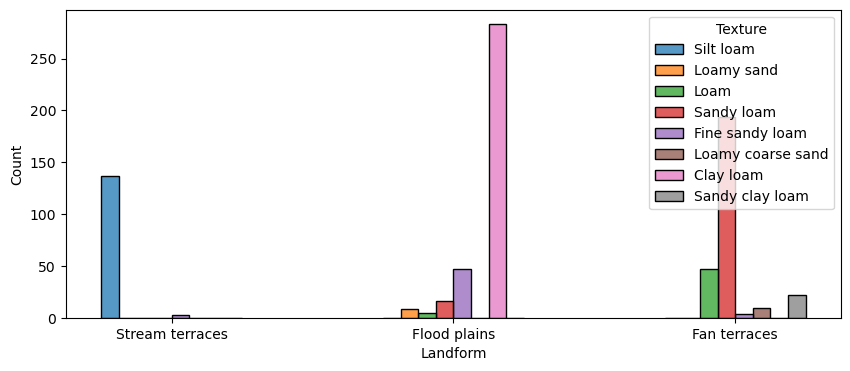

In [ ]:

fig, axes = plt.subplots(1, figsize = (10,4))
sns.histplot(data = data, x = 'Landform' , hue ='Texture', 
             shrink = 0.5, multiple ='dodge')


In [ ]:
def remove_legend_titles(obj):
    """
    Remove legend titles from:
      - a single Matplotlib Axes,
      - an iterable of Axes (e.g., np.ndarray from plt.subplots),
      - or a Seaborn FacetGrid/AxisGrid.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    def _clear(ax):
        leg = ax.get_legend()
        if leg is not None:
            leg.set_title(None)

    # Seaborn FacetGrid / AxisGrid
    if hasattr(obj, "axes") and hasattr(obj, "fig"):
        for ax in np.ravel(obj.axes):
            _clear(ax)
        return obj

    # Single Axes
    if hasattr(obj, "get_legend") and callable(obj.get_legend):
        _clear(obj)
        return obj

    # Iterable of Axes
    try:
        for ax in obj:
            _clear(ax)
        return obj
    except TypeError:
        raise TypeError("Expected an Axes, iterable of Axes, or a Seaborn FacetGrid/AxisGrid.")


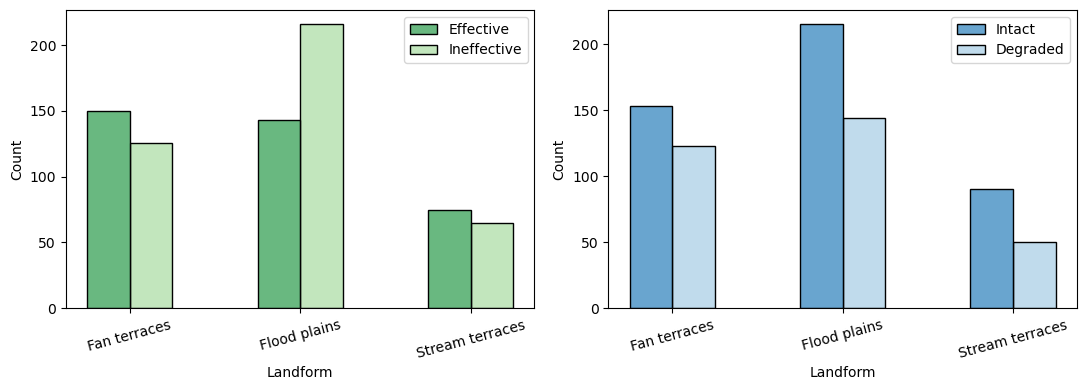

In [ ]:

plot_df = data.copy()

plot_df["Intact"] = pd.Categorical(
    np.where(plot_df["Intact"].astype(bool), "Intact", "Degraded"),
    categories=["Intact", "Degraded"], ordered=True
)

greens = sns.color_palette("Greens", 2)
blues  = sns.color_palette("Blues", 2)
palette_eff = {"Effective": greens[1], "Ineffective": greens[0]}
palette_int = {"Intact": blues[1], "Degraded": blues[0]}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Stability
sns.histplot(
    data=plot_df.sort_values("Landform"),
    x="Landform", hue="Effective", 
    multiple="dodge", shrink=0.5, stat="count", 
    palette=palette_eff, hue_order=["Effective", "Ineffective"],
    ax=axes[0], legend=True
)

# Intactness
sns.histplot(
    data=plot_df.sort_values("Landform"),
    x="Landform", hue="Intact", 
    hue_order=["Intact", "Degraded"], palette=palette_int,
    multiple="dodge", shrink=0.5, stat="count", 
    ax=axes[1], legend=True
)

# Title/position legends the seaborn way (no manual ax.legend() call)
try:
    sns.move_legend(axes[0], "upper right", title="", frameon=True)
    sns.move_legend(axes[1], "upper right", title="", frameon=True)
except Exception:
    # Fallback for older seaborn: retitle existing legends if present
    if axes[0].legend_ is not None: axes[0].legend_.set_title("Stability")
    if axes[1].legend_ is not None: axes[1].legend_.set_title("Intactness")

for ax in axes:
    ax.set_xlabel("Landform")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()

# agregating over 6 years; 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

thr = 60

df = data.query("Shape_Leng != @thr").copy()  # optional: drop exactly-60
df["len_bin"] = np.where(df["Shape_Leng"] > thr, f"Long (>{thr} m)", f"Short (<{thr} m)")
df["failed"] = df["Fail_Type"].ne("Intact")  # or: df["Intact"].eq(0)

# Unconditional outcome probabilities (Intact/Breach/Flank)
p_outcome = pd.crosstab(df["len_bin"], df["Fail_Type"], normalize="index")

# Overall failure probability
p_fail = df.groupby("len_bin")["failed"].mean().rename("Any failure")

# Conditional mix among failures only
p_mix_failed = pd.crosstab(
    df.loc[df["failed"], "len_bin"],
    df.loc[df["failed"], "Fail_Type"],
    normalize="index"
)

# Assemble a compact comparison table
metrics = pd.DataFrame({
    "Intact": p_outcome.get("Intact"),
    "Any failure": p_fail,
    "Breach": p_outcome.get("Breach"),
    "Flank": p_outcome.get("Flank"),
    "Breach | failed": p_mix_failed.get("Breach"),
    "Flank | failed": p_mix_failed.get("Flank"),
}).T

metrics.columns = metrics.columns  # (len_bin names)
metrics["Δ (pp)"] = (metrics.iloc[:, 0] - metrics.iloc[:, 1]) * 100
metrics["RR (Long/Short)"] = metrics.iloc[:, 0] / metrics.iloc[:, 1]

display((metrics.iloc[:, :2] * 100).round(1).assign(
    **{"Δ (pp)": metrics["Δ (pp)"].round(1),
       "RR (Long/Short)": metrics["RR (Long/Short)"].round(2)}
))



len_bin,Long (>60 m),Short (<60 m),Δ (pp),RR (Long/Short)
Intact,47.1,70.4,-23.4,0.67
Any failure,52.9,29.6,23.4,1.79
Breach,21.8,8.0,13.8,2.72
Flank,31.1,21.6,9.6,1.44
Breach | failed,41.2,27.1,14.1,1.52
Flank | failed,58.8,72.9,-14.1,0.81


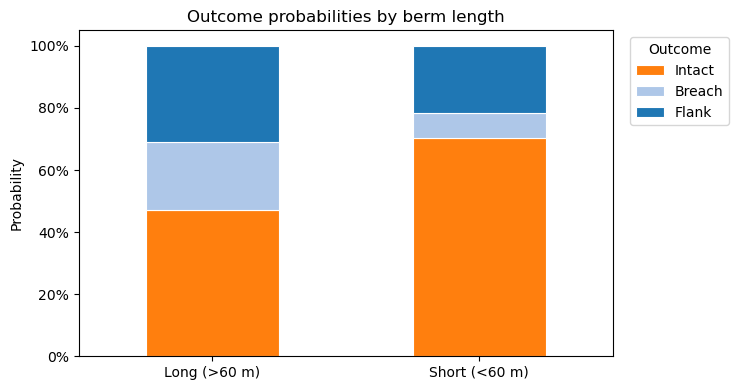

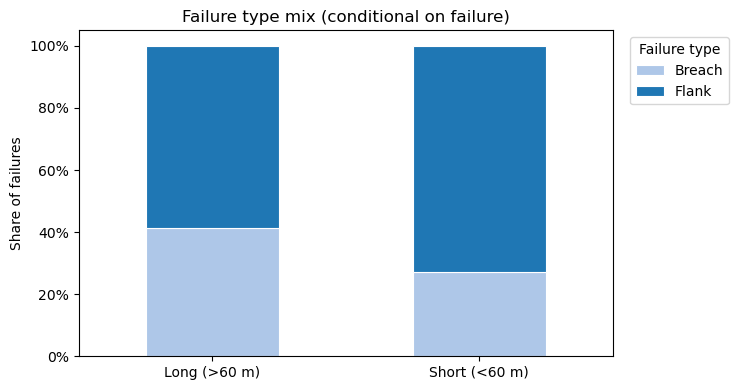

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# muted palette (pastel-ish)
cmap = plt.get_cmap("tab20")

outcome_order = ["Intact", "Breach", "Flank"]
outcome_colors = {
    "Intact": cmap(2),  # muted blue
    "Breach": cmap(1),  # muted orange
    "Flank":  cmap(0),  # muted green
}

# --- Plot 1: stacked outcomes (unconditional) ---
ax = p_outcome[outcome_order].plot(
    kind="bar", stacked=True, figsize=(7.5, 4),
    color=[outcome_colors[k] for k in outcome_order],
    edgecolor="white", linewidth=0.8
)
ax.set_ylabel("Probability")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Outcome probabilities by berm length")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# --- Plot 2: among failures only (conditional) ---
fail_order = ["Breach", "Flank"]
ax = p_mix_failed[fail_order].plot(
    kind="bar", stacked=True, figsize=(7.5, 4),
    color=[outcome_colors[k] for k in fail_order],
    edgecolor="white", linewidth=0.8
)
ax.set_ylabel("Share of failures")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Failure type mix (conditional on failure)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Failure type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

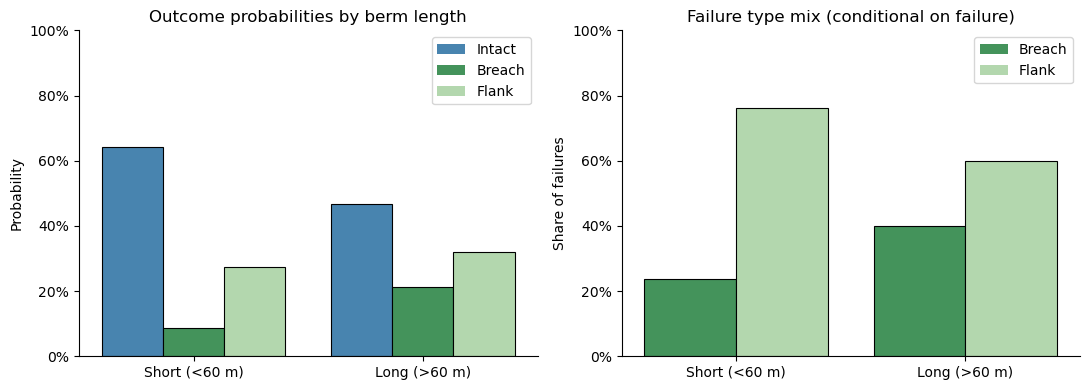

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

thr = 60

plot_df = data.query("Type == 'Berm'").copy() if "Type" in data.columns else data.copy()
plot_df = plot_df.query("Shape_Leng != @thr").copy()  # optional: drop exactly-60

short_lbl = f"Short (<{thr} m)"
long_lbl  = f"Long (>{thr} m)"

plot_df["len_bin"] = pd.Categorical(
    np.where(plot_df["Shape_Leng"] > thr, long_lbl, short_lbl),
    categories=[short_lbl, long_lbl], ordered=True
)
plot_df["failed"] = plot_df["Fail_Type"].ne("Intact")

# ---- probabilities (tidy) ----
p_outcome = pd.crosstab(plot_df["len_bin"], plot_df["Fail_Type"], normalize="index")
out_long = p_outcome.reset_index().melt(id_vars="len_bin", var_name="Fail_Type", value_name="prob")

p_mix_failed = pd.crosstab(
    plot_df.loc[plot_df["failed"], "len_bin"],
    plot_df.loc[plot_df["failed"], "Fail_Type"],
    normalize="index"
)
mix_long = p_mix_failed.reset_index().melt(id_vars="len_bin", var_name="Fail_Type", value_name="prob")

# ---- palettes (match your existing vibe) ----
greens = sns.color_palette("Greens", 2)
blues  = sns.color_palette("Blues", 2)
palette_outcome = {"Intact": blues[1], "Breach": greens[1], "Flank": greens[0]}

# stable hue orders
base_order = ["Intact", "Breach", "Flank"]
fail_order = [c for c in base_order if c in out_long["Fail_Type"].unique()] + \
             [c for c in out_long["Fail_Type"].unique() if c not in base_order]
mix_order = [c for c in ["Breach", "Flank"] if c in mix_long["Fail_Type"].unique()]

def add_bar_edges(ax, lw=0.8):
    for p in ax.patches:
        p.set_edgecolor("black")
        p.set_linewidth(lw)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes = axes.ravel()

# Panel 1: unconditional outcome probs (grouped bars)
sns.barplot(
    data=out_long,
    x="len_bin", y="prob", hue="Fail_Type",
    hue_order=fail_order, palette=palette_outcome,
    errorbar=None, ax=axes[0]
)
add_bar_edges(axes[0])
axes[0].set_title("Outcome probabilities by berm length")
axes[0].set_xlabel("")
axes[0].set_ylabel("Probability")
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].tick_params(axis="x", rotation=0)

# Panel 2: conditional failure mix (grouped bars)
sns.barplot(
    data=mix_long.query("Fail_Type in @mix_order"),
    x="len_bin", y="prob", hue="Fail_Type",
    hue_order=mix_order, palette=palette_outcome,
    errorbar=None, ax=axes[1]
)
add_bar_edges(axes[1])
axes[1].set_title("Failure type mix (conditional on failure)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Share of failures")
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].tick_params(axis="x", rotation=0)

# seaborn-style legend placement + clean spines
try:
    sns.move_legend(axes[0], "upper right", title="", frameon=True)
    sns.move_legend(axes[1], "upper right", title="", frameon=True)
except Exception:
    pass

for ax in axes:
    sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()

In [ ]:

print("Probability of a failure given a berm is long:", 
len(data.query("Shape_Leng > 60 and Fail_Type != 'Intact'"))/len(data.query("Shape_Leng > 60")), 
"\nProbability of a failure given a berm is short:",
len(data.query("Shape_Leng < 60 and Fail_Type != 'Intact'"))/len(data.query("Shape_Leng < 60")))


print("Probability of a breach given a berm is long:", 
len(data.query("Shape_Leng > 60 and Fail_Type == 'Breach'"))/len(data.query("Shape_Leng > 60")), 
"\nProbability of a breach given a berm is short:",
len(data.query("Shape_Leng < 60 and Fail_Type == 'Breach'"))/len(data.query("Shape_Leng < 60")))

print("\n\nProbability of a flank given a berm is long:", 
len(data.query("Shape_Leng > 60 and Fail_Type == 'Flank'"))/len(data.query("Shape_Leng > 60")), 
"\nProbability of a flank given a berm is short:",
len(data.query("Shape_Leng < 60 and Fail_Type == 'Flank'"))/len(data.query("Shape_Leng < 60")))


print("Probability of a flank given a berm is long and failed:", 
len(data.query("Shape_Leng > 60 and Fail_Type == 'Flank' and Intact == 0"))/len(data.query("Shape_Leng > 60 and Intact == 0")), 
"\nProbability of a flank given a berm is short and failed:",
len(data.query("Shape_Leng < 60 and Fail_Type == 'Flank' and Intact == 0"))/len(data.query("Shape_Leng < 60 and Intact == 0")))

print("Probability of a breach given a berm long and failed:",
len(data.query("Shape_Leng > 60 and Fail_Type == 'Breach' and Intact == 0"))/len(data.query("Shape_Leng > 60 and Intact == 0")), 
"\nProbability of a breach given a berm is short and failed:",
len(data.query("Shape_Leng < 60 and Fail_Type == 'Breach' and Intact == 0"))/len(data.query("Shape_Leng < 60 and Intact == 0")))


Probability of a failure given a berm is long: 0.5292553191489362 
Probability of a failure given a berm is short: 0.2957393483709273
Probability of a breach given a berm is long: 0.21808510638297873 
Probability of a breach given a berm is short: 0.08020050125313283


Probability of a flank given a berm is long: 0.31117021276595747 
Probability of a flank given a berm is short: 0.21553884711779447
Probability of a flank given a berm is long and failed: 0.5879396984924623 
Probability of a flank given a berm is short and failed: 0.7288135593220338
Probability of a breach given a berm long and failed: 0.4120603015075377 
Probability of a breach given a berm is short and failed: 0.2711864406779661


In [ ]:
data.groupby("Effective")[['FA_30_max', 'FA_60_max']].median()/1000
# tend to have longer flow accumulation in ineffective berms

,FA_30_max,FA_60_max
Effective,,
Effective,1.667,3.1595
Ineffective,2.562,9.1800


In [ ]:
data.groupby("Intact")[['FA_30_max', 'FA_60_max']].median()/1000
# tend to have longer flow accumulation in ineffective berms

,FA_30_max,FA_60_max
Intact,,
False,4.5480,9.629
True,1.0595,2.708


In [ ]:
import numpy as np
import pandas as pd

df = data.copy()
df["is_effective"] = (df["Effective"] == "Effective")
df["is_degraded"]  = (~df["Intact"])            # degraded = Intact==False

# counts + rates
ct = (
    df.groupby(["Landform", "is_degraded"])["is_effective"]
      .agg(N="size", p_effective="mean")
      .reset_index()
)

ct


,Landform,is_degraded,N,p_effective
0,Fan terraces,False,153,0.535948
1,Fan terraces,True,123,0.552846
2,Flood plains,False,215,0.386047
3,Flood plains,True,144,0.416667
4,Stream terraces,False,90,0.544444
5,Stream terraces,True,50,0.520000


In [ ]:
ct = (
    df.groupby(["Soil_Development", "is_degraded"])["is_effective"]
      .agg(N="size", p_effective="mean")
      .reset_index()
)

ct

,Soil_Development,is_degraded,N,p_effective
0,B horizon,False,158,0.531646
1,B horizon,True,131,0.580153
2,No B horizon,False,300,0.433333
3,No B horizon,True,186,0.419355


In [ ]:
data.groupby(["Landform", "Intact"])[['FA_30_max', 'FA_60_max']].median().reset_index()

,Landform,Intact,FA_30_max,FA_60_max
0,Fan terraces,False,2674.0,3369.0
1,Fan terraces,True,764.0,1454.0
2,Flood plains,False,33430.0,67159.5
3,Flood plains,True,2299.0,18904.0
4,Stream terraces,False,2226.0,3678.0
5,Stream terraces,True,786.0,3053.5


array([<Axes: xlabel='Landform', ylabel='Median FA_60_max'>,
       <Axes: xlabel='Landform', ylabel='Flow accumulation'>],
      dtype=object)

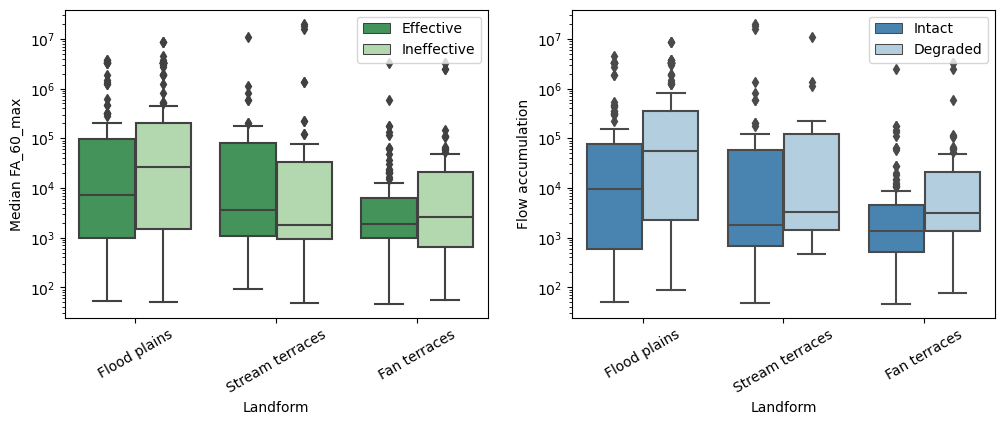

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes = axes.ravel()

balanced_data = data.query("Type == 'Berm'").copy() if "Type" in data.columns else data.copy()

# consistent Landform order across panels (by overall median FA_60_max)
landform_order = (
    balanced_data.groupby("Landform")["FA_60_max"]
    .median().sort_values(ascending=False).index.tolist()
)

# helper: remove top+left spines, add bar outlines, log y
def style_bar_ax(ax):
    sns.despine(ax=ax, top=True)
    for p in ax.patches:
        p.set_edgecolor("black")
        p.set_linewidth(0.8)
    ax.set_yscale("log")

    # make sure the bottom is > 0 on log scale
    heights = [p.get_height() for p in ax.patches if np.isfinite(p.get_height()) and p.get_height() > 0]
    if heights:
        ax.set_ylim(bottom=min(heights) / 2)

eps = 1e-6  # only used if any medians are 0 (log scale needs >0)

# --- Panel 1: FA_60_max by Landform, hue=Effective ---
eff_med = (
    balanced_data.groupby(["Landform", "Effective"], dropna=False)[["FA_60_max"]]
    .median()
    .reset_index()
)
eff_med["FA_60_max"] = eff_med["FA_60_max"].clip(lower=eps)

sns.boxplot(
    data=balanced_data, x="Landform", y="FA_60_max", hue="Effective",
    order=landform_order,
    hue_order=["Effective", "Ineffective"],
    palette=palette_eff,
#     errorbar=None,
    ax=axes[0],
)
axes[0].set_xlabel("Landform")
axes[0].set_ylabel("Median FA_60_max")
axes[0].tick_params(axis="x", rotation=30)
# style_bar_ax(axes[0])
axes[0].set_yscale('log')

# --- Panel 2: FA_60_max by Landform, hue=Condition/Intact ---
if "Condition" in balanced_data.columns:
    cond_col = "Condition"
    hue_order = ["Intact", "Degraded"]
    bd2 = balanced_data

cond_med = (
    bd2.groupby(["Landform", cond_col], dropna=False)[["FA_60_max"]]
    .median()
    .reset_index()
    .rename(columns={cond_col: "Condition"})
)
cond_med["FA_60_max"] = cond_med["FA_60_max"].clip(lower=eps)

sns.boxplot(
    data=balanced_data, x="Landform", y="FA_60_max", hue="Condition",
    order=landform_order,
    hue_order=hue_order,
    palette=palette_int,
#     errorbar=None,
    ax=axes[1],
)
axes[1].set_xlabel("Landform")
axes[1].set_ylabel("Flow accumulation")
axes[1].tick_params(axis="x", rotation=30)
# style_bar_ax(axes[1])
axes[1].set_yscale('log')
remove_legend_titles(axes)


<Axes: xlabel='Landform', ylabel='FA_60_max'>

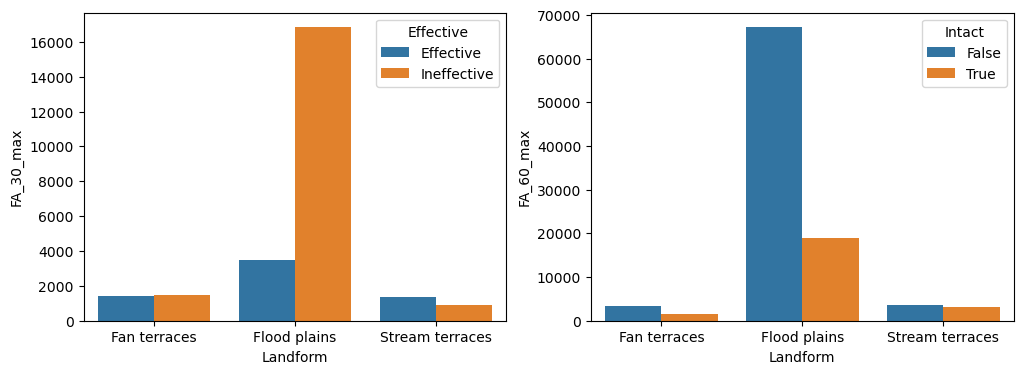

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes = axes.ravel()


sns.barplot(data.groupby(["Landform", "Effective"])[['FA_30_max', 'FA_60_max']].median().reset_index(),
            x = "Landform", y = 'FA_30_max',  ax = axes[0], hue = 'Effective')

sns.barplot(data.groupby(["Landform", "Intact"])[['FA_30_max', 'FA_60_max']].median().reset_index(), x = "Landform",
            y = 'FA_60_max', ax = axes[1], hue = 'Intact')


array([<Axes: xlabel='Direction', ylabel='Count'>,
       <Axes: xlabel='Direction', ylabel='Count'>], dtype=object)

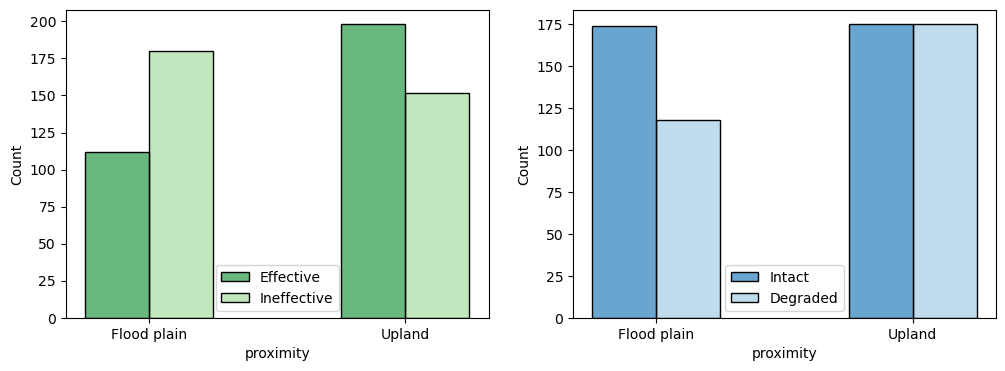

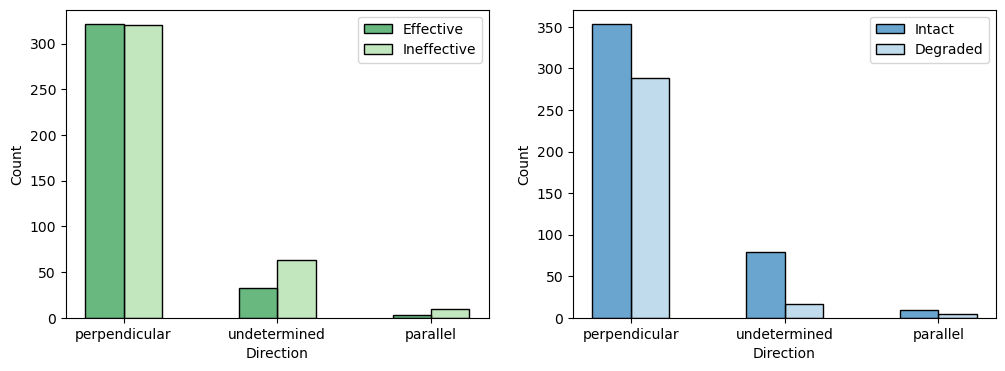

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (12,4))
balanced_data = data.query("Type == 'Berm'")
axes = axes.ravel()

sns.histplot (data = balanced_data.sort_values("proximity"), x = 'proximity' ,  
              hue ='Effective', ax= axes[0], stat = 'count',
              palette=palette_eff, hue_order=["Effective", "Ineffective"],
              shrink = 0.5, multiple ='dodge')


sns.histplot (data = balanced_data.sort_values("proximity"), x = 'proximity' ,  
              hue ='Condition',ax= axes[1], stat = 'count',
              hue_order=["Intact", "Degraded"], palette=palette_int,
              shrink = 0.5, multiple ='dodge')


remove_legend_titles(axes)



fig, axes = plt.subplots(1, 2, figsize = (12,4))
balanced_data = merged
axes = axes.ravel()

sns.histplot (data = balanced_data.sort_values("landform"), x = 'Direction' ,  
              hue ='Effective',ax= axes[0], stat = 'count',
              palette=palette_eff, hue_order=["Effective", "Ineffective"], 
              shrink = 0.5, multiple ='dodge')


sns.histplot (data = balanced_data.sort_values("landform"), x = 'Direction' ,  
              hue ='Condition',ax= axes[1], stat = 'count',
              hue_order=["Intact", "Degraded"], palette=palette_int,
              shrink = 0.5, multiple ='dodge')


remove_legend_titles(axes)
# berms on flood plains tend to be intact and ineffective
# berms on uplands tend to be effective, equal parts intact and degraded.

array([<Axes: xlabel='Slope Class', ylabel='Count'>,
       <Axes: xlabel='Slope Class', ylabel='Count'>,
       <Axes: xlabel='Slope Class', ylabel='Count'>], dtype=object)

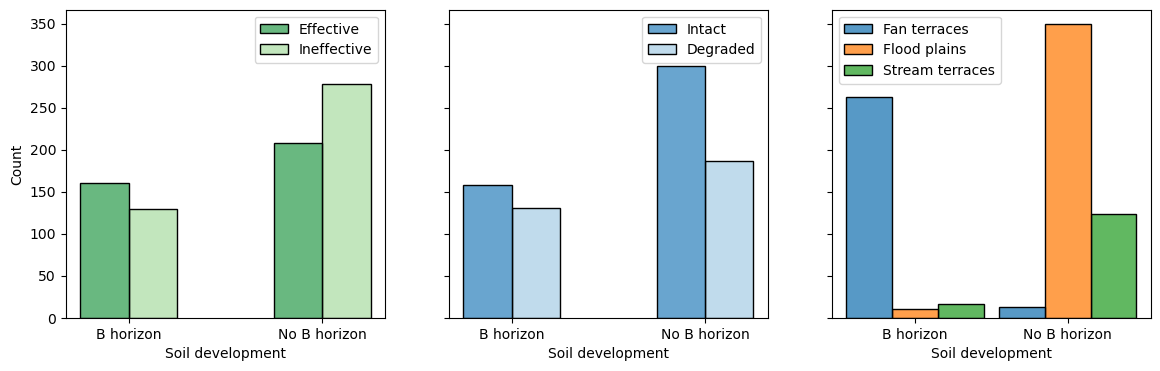

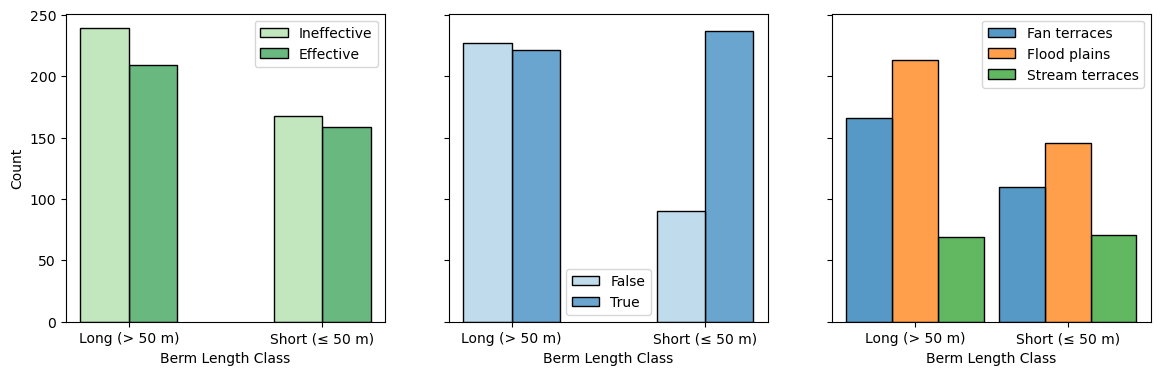

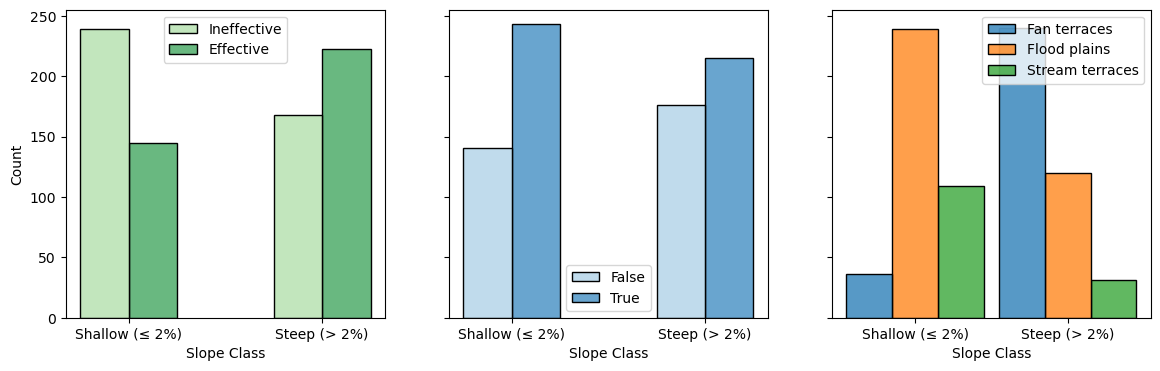

In [ ]:
fig, axes = plt.subplots(1, 3, figsize = (14,4), sharey = True)
axes = axes.ravel()

sns.histplot (data = data.sort_values("Soil_Development",ascending =  True), x = 'Soil_Development' ,  
              hue ='Effective',ax= axes[0], stat = 'count',
              shrink = 0.5, multiple ='dodge', 
              palette=palette_eff, hue_order=["Effective", "Ineffective"])

axes[0].set_xlabel("Soil development")
sns.histplot (data = data.sort_values("Soil_Development",ascending =  True), x = 'Soil_Development' ,  
              hue ='Condition',ax= axes[1], stat = 'count',
              shrink = 0.5, multiple ='dodge', 
              hue_order=["Intact", "Degraded"], palette=palette_int)
axes[1].set_xlabel("Soil development")

sns.histplot (data = data.sort_values("Landform",ascending =  True), x = 'Soil_Development' ,  
              hue ='Landform',ax= axes[2], stat = 'count',
              shrink = 0.9, multiple ='dodge', palette = ['C0', 'C1', 'C2'])
axes[2].set_xlabel("Soil development")


remove_legend_titles(axes)


fig, axes = plt.subplots(1, 3, figsize = (14,4), sharey = True)
axes = axes.ravel()

sns.histplot (data = data.sort_values("Berm_Length_Class",ascending =  True), x = 'Berm_Length_Class' ,  
              hue ='Effective',ax= axes[0], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Greens')
axes[0].set_xlabel("Berm Length Class")

sns.histplot (data = data.sort_values("Berm_Length_Class",ascending =  True), x = 'Berm_Length_Class' ,  
              hue ='Intact',ax= axes[1], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Blues')
axes[1].set_xlabel("Berm Length Class")

sns.histplot (data = data.sort_values("Landform",ascending =  True), x = 'Berm_Length_Class' ,  
              hue ='Landform',ax= axes[2], stat = 'count',
              shrink = 0.9, multiple ='dodge', palette = ['C0', 'C1', 'C2'])
axes[2].set_xlabel("Berm Length Class")

remove_legend_titles(axes)



fig, axes = plt.subplots(1, 3, figsize = (14,4), sharey = True)
axes = axes.ravel()

sns.histplot (data = data.sort_values("Slope_Class",ascending =  True), x = 'Slope_Class' ,  
              hue ='Effective',ax= axes[0], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Greens')
axes[0].set_xlabel("Slope Class")

sns.histplot (data = data.sort_values("Slope_Class",ascending =  True), x = 'Slope_Class' ,  
              hue ='Intact',ax= axes[1], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Blues')
axes[1].set_xlabel("Slope Class")

sns.histplot (data = data.sort_values("Landform",ascending =  True), x = 'Slope_Class' ,  
              hue ='Landform',ax= axes[2], stat = 'count',
              shrink = 0.9, multiple ='dodge', palette = ['C0', 'C1', 'C2'])
axes[2].set_xlabel("Slope Class")
remove_legend_titles(axes)


array([<Axes: xlabel='Landform', ylabel='Count'>], dtype=object)

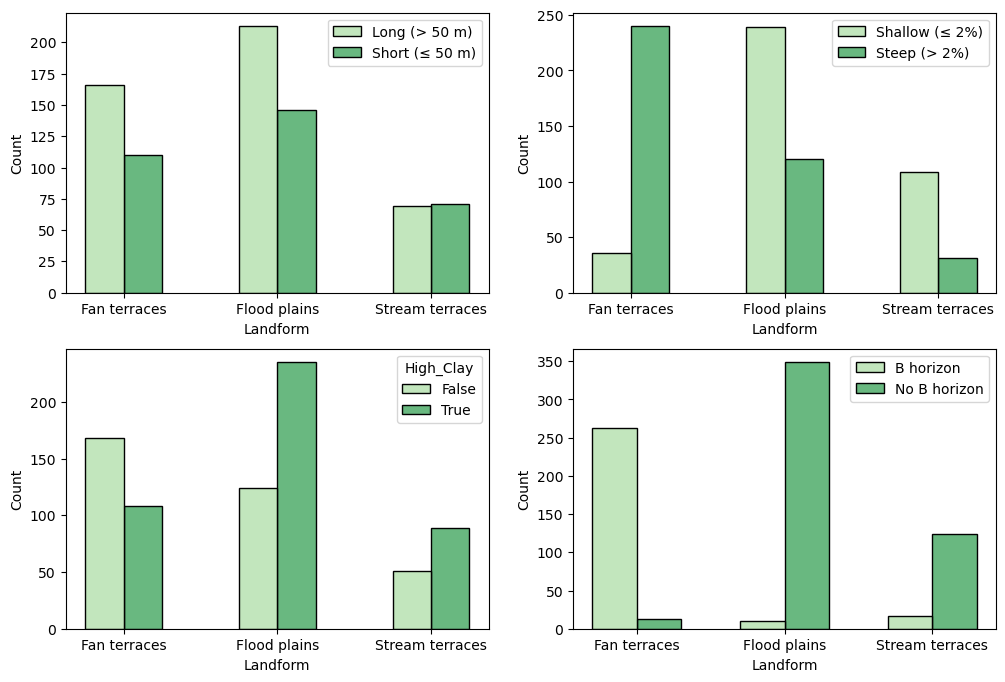

In [ ]:

fig, axes = plt.subplots(2, 2, figsize = (12,8))
axes = axes.ravel()
sns.histplot (data = data.sort_values("Landform", ascending =  True), x = 'Landform' , 
              hue ='Berm_Length_Class',ax= axes[0], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Greens')


sns.histplot (data = data.sort_values("Landform", ascending =  True), x = 'Landform' , 
              hue ='Slope_Class',ax= axes[1], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Greens')


sns.histplot (data = data.sort_values("Landform", ascending =  True), x = 'Landform' , 
              hue ='High_Clay',ax= axes[2], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Greens')

sns.histplot (data = data.sort_values("Landform", ascending =  True), x = 'Landform' , 
              hue ='Soil_Development',ax= axes[3], stat = 'count',
              shrink = 0.6, multiple ='dodge', palette = 'Greens')

remove_legend_titles(axes[0:2])
remove_legend_titles(axes[3:])

# Fan terraces are more effective because steeper,
# possibly because steeper (more runoff capture), possibly lower clay and no B horizon? 

# Floodplains less effective because gentle slopes, 
# possibly high clay

# different reasons, design criteria, inherent differnces.
# characteristics take away ..
 

### Potential SI Figures

In [ ]:
def analyze_threshold_proportions(data, threshold_var, threshold_name, bins, largeName = 'Large', 
                                     smallName = 'Small'):
    results = []

    for threshold in bins:
        high = data.query("{0} > @threshold".format(threshold_var))
        low = data.query("{0} <= @threshold".format(threshold_var))

        # Degraded counts
        high_degraded = (high['Condition'] == 'Degraded').sum()
        high_intact = (high['Condition'] == 'Intact').sum()
        low_degraded = (low['Condition'] == 'Degraded').sum()
        low_intact = (low['Condition'] == 'Intact').sum()

        total_high = high_degraded + high_intact
        total_low = low_degraded + low_intact
        prop_degraded_high = high_degraded / total_high if total_high > 0 else np.nan
        prop_degraded_low = low_degraded / total_low if total_low > 0 else np.nan

        # Effective counts
        high_effective = (high['effective'] == 1).sum()
        high_ineffective = (high['effective'] == 0).sum()
        low_effective = (low['effective'] == 1).sum()
        low_ineffective = (low['effective'] == 0).sum()

        total_high_eff = high_effective + high_ineffective
        total_low_eff = low_effective + low_ineffective
        prop_effective_high = high_effective / total_high_eff if total_high_eff > 0 else np.nan
        prop_effective_low = low_effective / total_low_eff if total_low_eff > 0 else np.nan

        # Contingency tables
        table_degraded = [[low_degraded, low_intact],
                           [high_degraded, high_intact]]
        table_effective = [[low_effective, low_ineffective],
                            [high_effective, high_ineffective]]

        # Significance tests - degraded
        try:
            fisher_p = fisher_exact(table_degraded)[1]
        except:
            fisher_p = np.nan
        try:
            chi2_p = chi2_contingency(table_degraded)[1]
        except:
            chi2_p = np.nan

        # Significance tests - effective
        try:
            fisher_p_eff = fisher_exact(table_effective)[1]
        except:
            fisher_p_eff = np.nan
        try:
            chi2_p_eff = chi2_contingency(table_effective)[1]
        except:
            chi2_p_eff = np.nan

        results.append({
            'threshold': threshold,
            'high_proportion_degraded': prop_degraded_high,
            'low_proportion_degraded': prop_degraded_low,
            'high_proportion_effective': prop_effective_high,
            'low_proportion_effective': prop_effective_low,
            'fisher_p_degraded': fisher_p,
            'chi2_p_degraded': chi2_p,
            'significant_degraded': fisher_p < 0.05 if not np.isnan(fisher_p) else False,
            'fisher_p_effective': fisher_p_eff,
            'chi2_p_effective': chi2_p_eff,
            'significant_effective': fisher_p_eff < 0.05 if not np.isnan(fisher_p_eff) else False,
            # Include counts
            'high_degraded': high_degraded,
            'high_intact': high_intact,
            'low_degraded': low_degraded,
            'low_intact': low_intact,
            'high_effective': high_effective,
            'high_ineffective': high_ineffective,
            'low_effective': low_effective,
            'low_ineffective': low_ineffective,
            # Total counts for filtering
            'total_high': total_high,
            'total_low': total_low
        })

    results_df = pd.DataFrame(results)

    # Filter: only show thresholds with at least 15 samples in either low or high
    filtered_df = results_df.query("high_degraded >= 10 and  low_degraded >= 10")

    # Plotting
    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True, sharey = True)
    high_color = "C1"
    low_color = "C0"

    sig_degraded = filtered_df['significant_degraded']
    sig_effective = filtered_df['significant_effective']

    # Panel: Degraded Fraction
    sns.scatterplot(
        data=filtered_df, x='threshold', y='low_proportion_degraded',
        ax=axes[0], color=low_color, marker='o', label="{1} {0}".format(threshold_name, smallName), alpha=0.5,
    )
    sns.scatterplot(
        data=filtered_df[sig_degraded], x='threshold', y='low_proportion_degraded',
        ax=axes[0], color=low_color, marker='s',
    )
    sns.scatterplot(
        data=filtered_df, x='threshold', y='high_proportion_degraded',
        ax=axes[0], color=high_color, marker='o', label="{1} {0}".format(threshold_name, largeName), alpha=0.5
    )
    sns.scatterplot(
        data=filtered_df[sig_degraded], x='threshold', y='high_proportion_degraded',
        ax=axes[0], color=high_color, marker='s',
    )
    axes[0].set_title("Degraded Fraction")
    axes[0].set_ylabel("Degraded Fraction")
    axes[0].legend()

    #filtered_df = results_df.query("high_effective >= 10 and  low_effective >= 10")    
    # Panel 2: Effective Fraction
    sns.scatterplot(
        data=filtered_df, x='threshold', y='low_proportion_effective',
        ax=axes[1], color=low_color, marker='o', label="{1} {0}".format(threshold_name, smallName), alpha=0.5
    )
    sns.scatterplot(
        data=filtered_df[sig_effective], x='threshold', y='low_proportion_effective',
        ax=axes[1], color=low_color, marker='s',
    )
    sns.scatterplot(
        data=filtered_df, x='threshold', y='high_proportion_effective',
        ax=axes[1], color=high_color, marker='o', label="{1} {0}".format(threshold_name, largeName), alpha=0.5
    )
    sns.scatterplot(
        data=filtered_df[sig_effective], x='threshold', y='high_proportion_effective',
        ax=axes[1], color=high_color, marker='s',
    )
    axes[1].set_title(r"'Effective' fraction ($\Delta S > 10$)")
    axes[1].set_xlabel("{0} threshold".format(threshold_name))
    axes[1].set_ylabel("Effective Fraction")
    axes[1].legend()

    plt.tight_layout()

    return results_df, fig


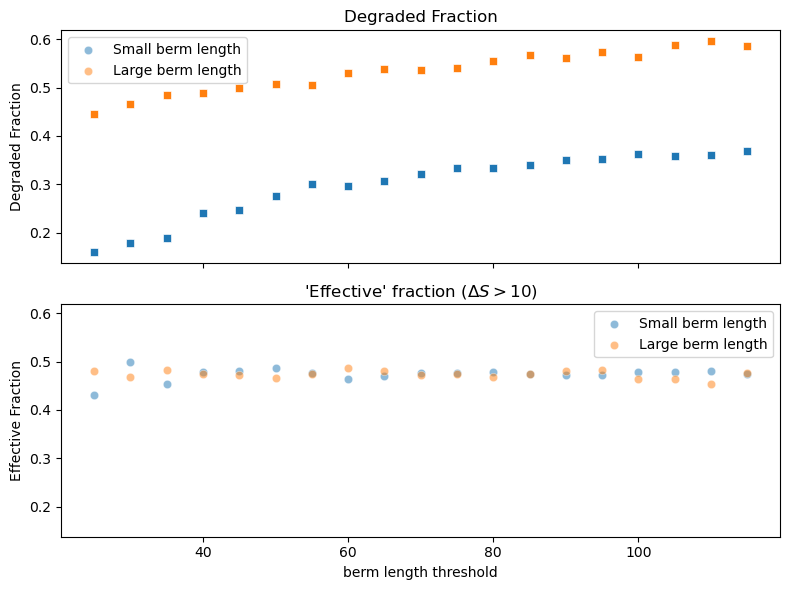

In [ ]:
# Example usage:
results_df, fig = analyze_threshold_proportions(data, 'Shape_Leng', 'berm length', np.arange(0, 120, 5))
# fig.savefig('../figures/single_variable_plots/Shape_Leng.png')

In [ ]:
[c for c in data if 'slope' in c]

['slopeD_100',
 'slopeD_200',
 'slopeD_60',
 'slopeU_100',
 'slopeU_200',
 'slopeU_60',
 'slope_100',
 'slope_200']

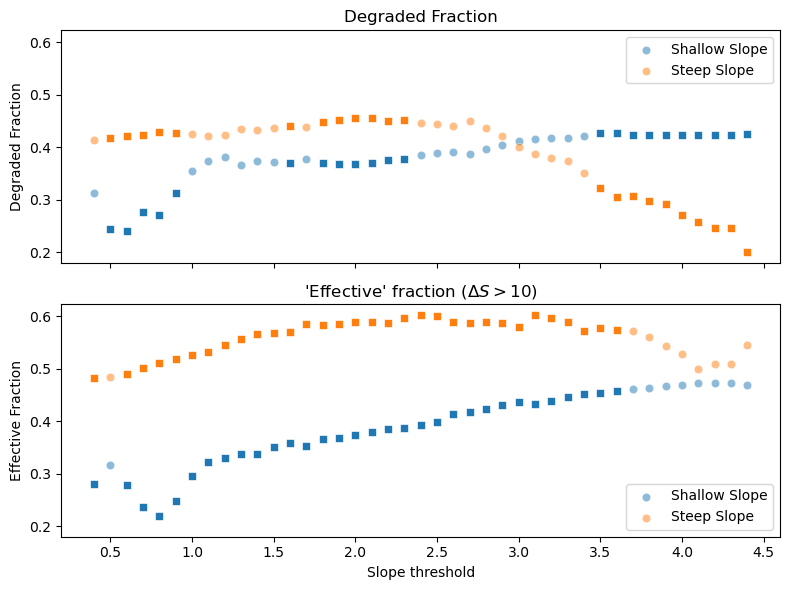

In [ ]:
results_df, fig = analyze_threshold_proportions(data, 'slope_200', 'Slope', np.arange(0, 10, 0.1), largeName = 'Steep', smallName = 'Shallow' )
# fig.savefig('../figures/single_variable_plots/Slope.png')

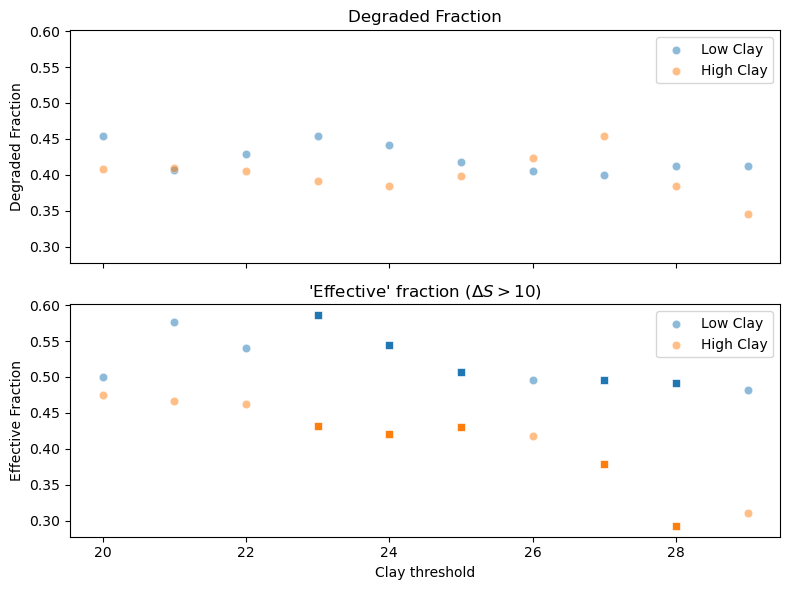

In [ ]:
results_df, fig = analyze_threshold_proportions(data, 'surf_claybg', 'Clay', np.arange(18, 30, 1), 
                                                largeName = 'High', smallName = 'Low' )
# fig.savefig('../figures/single_variable_plots/Clay.png')

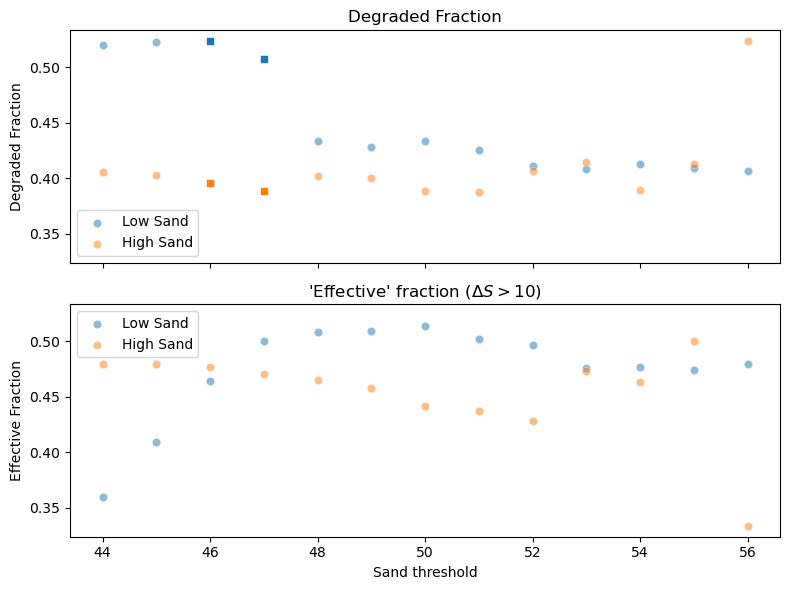

In [ ]:
results_df, fig = analyze_threshold_proportions(data, 'surf_sandbg', 'Sand', np.arange(40, 60, 1), 
                                                largeName = 'High', smallName = 'Low' )
# fig.savefig('../figures/single_variable_plots/Sand.png')

## Balancing samples

In [ ]:
import pandas as pd


def balanced_sample(df, group_cols, partition_col):
    # Drop rows with missing values in relevant columns
    cols_required = group_cols + [partition_col]
    df = df.dropna(subset=cols_required)

    grouped = df.groupby(group_cols + [partition_col])
    ct = grouped.size().unstack(partition_col, fill_value=0)

    samples = []
    for idx, row in ct.iterrows():
        partition_values = row.index.tolist()
        min_n = row.min()

        # Skip unbalanced groups
        if row.nunique() == 1 or min_n == 0:
            print(f"Skipping unbalanced group: {idx} | Counts: {row.to_dict()}")
            continue

        group_filter = dict(zip(group_cols, idx if isinstance(idx, tuple) else (idx,)))
        for part_value in partition_values:
            subset = df.copy()
            for col, val in group_filter.items():
                subset = subset[subset[col] == val]
            subset = subset[subset[partition_col] == part_value]
            samples.append(subset.sample(n=min_n, random_state=42))

    return pd.concat(samples).reset_index(drop=True)



In [ ]:
partition_col = 'Landform'

# Open file for writing
with open('landform_summary.txt', 'w') as f:
    f.write("\nUnbalanced effective:\n")
    
    summary_counts = data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    f.write("\nBerm Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    f.write("\nUnbalanced intact:\n")
    summary_counts = data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm intact Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    
    f.write("\n Berm length / landform correspondence")
    
    f.write("\nUnbalanced intact:\n")
    summary_counts = data.groupby([partition_col, 'Berm_Length_Class']).size().unstack(fill_value=0)
    f.write("\nBerm intact Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
    
    f.write("\n Slope  / landform correspondence")
    
    summary_counts = data.groupby([partition_col, 'Slope_Class']).size().unstack(fill_value=0)
    f.write("\nBerm Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")    
    
 

In [ ]:
partition_col = 'Soil_Development'

# Open file for writing
with open('soil_summary.txt', 'w') as f:
    f.write("\nUnbalanced effective:\n")
    
    summary_counts = data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    f.write("\nBerm effective Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    f.write("\nUnbalanced intact:\n")
    summary_counts = data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm intact Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    

    group_cols = ['Slope_Class']   
    f.write("-------\n")
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    

    # Apply balancing function
    balanced_data = balanced_sample(data, group_cols=group_cols, partition_col=partition_col)

    # Split and summarize
    partitions = balanced_data[partition_col].unique()
    f.write("\nSample sizes per partition:\n")
    for part in partitions:
        count = balanced_data[balanced_data[partition_col] == part].shape[0]
        f.write(f"{part}: {count}\n")

    f.write("\nSample breakdown by group:\n")
    group_counts = balanced_data.groupby([partition_col] + group_cols).size()
    f.write(group_counts.to_string())
    f.write("\n")
    
    
    summary_counts = balanced_data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    summary_counts = balanced_data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
 
    group_cols = ['Slope_Class', 'Berm_Length_Class']    

    f.write("-------\n")
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    

    # Apply balancing function
    balanced_data = balanced_sample(data, group_cols=group_cols, partition_col=partition_col)

    # Split and summarize
    partitions = balanced_data[partition_col].unique()
    f.write("\nSample sizes per partition:\n")
    for part in partitions:
        count = balanced_data[balanced_data[partition_col] == part].shape[0]
        f.write(f"{part}: {count}\n")

    f.write("\nSample breakdown by group:\n")
    group_counts = balanced_data.groupby([partition_col] + group_cols).size()
    f.write(group_counts.to_string())
    f.write("\n")

    
    summary_counts = balanced_data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    
    f.write("\n")
    f.write("\nBerm counts  :\n")
    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
  
    summary_counts = balanced_data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
 

In [ ]:
# Choose grouping and partition variables
partition_col = 'Slope_Class'

# Open file for writing
with open('slope_summary.txt', 'w') as f:
    f.write("\nUnbalanced effective:\n")
    
    summary_counts = data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    f.write("\nBerm effective Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    f.write("\nUnbalanced intact:\n")
    summary_counts = data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm intact Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    

    group_cols = ['Landform']    
    f.write("-------\n")
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    

    # Apply balancing function
    balanced_data = balanced_sample(data, group_cols=group_cols, partition_col=partition_col)

    # Split and summarize
    partitions = balanced_data[partition_col].unique()
    f.write("\nSample sizes per partition:\n")
    for part in partitions:
        count = balanced_data[balanced_data[partition_col] == part].shape[0]
        f.write(f"{part}: {count}\n")

    f.write("\nSample breakdown by group:\n")
    group_counts = balanced_data.groupby([partition_col] + group_cols).size()
    f.write(group_counts.to_string())
    f.write("\n")
    
    
    summary_counts = balanced_data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    summary_counts = balanced_data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
 
    group_cols = ['Landform', 'Berm_Length_Class']    

    f.write("-------\n")
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    

    # Apply balancing function
    balanced_data = balanced_sample(data, group_cols=group_cols, partition_col=partition_col)

    # Split and summarize
    partitions = balanced_data[partition_col].unique()
    f.write("\nSample sizes per partition:\n")
    for part in partitions:
        count = balanced_data[balanced_data[partition_col] == part].shape[0]
        f.write(f"{part}: {count}\n")

    f.write("\nSample breakdown by group:\n")
    group_counts = balanced_data.groupby([partition_col] + group_cols).size()
    f.write(group_counts.to_string())
    f.write("\n")

    
    summary_counts = balanced_data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    
    f.write("\n")
    f.write("\nBerm counts  :\n")
    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
  
    summary_counts = balanced_data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
 

## Significance tests

In [ ]:
import numpy as np
import pandas as pd
from itertools import combinations
from scipy.stats import chi2_contingency, fisher_exact, norm

def _auto_positive(series, outcome_name):
    # Determine the "positive" value for a binary series
    v = pd.Series(series.dropna().unique())
    if series.dtype == bool or set(v) <= {True, False}:
        return True
    if set(v) <= {0, 1}:
        return 1
    # try common labels
    if outcome_name.lower().startswith("effect"):
        for cand in ["Effective", "effective", "Yes", "yes", "Positive"]:
            if cand in set(v):
                return cand
    if outcome_name.lower().startswith("intact"):
        for cand in ["Intact", "intact", "Yes", "yes", "Positive"]:
            if cand in set(v):
                return cand
    # fallback: pick the first value
    return v.iloc[0]

def chi2_with_cramers_v(ct: pd.DataFrame):
    chi2, p, dof, expected = chi2_contingency(ct)
    n = ct.values.sum()
    r, k = ct.shape
    V = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    return chi2, p, dof, V, expected

def _two_prop_z(count1, n1, count2, n2):
    # pooled two-proportion z test (two-sided)
    p1, p2 = count1/n1, count2/n2
    p_pool = (count1 + count2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    if se == 0: 
        return 0.0, 1.0, p1 - p2
    z = (p1 - p2) / se
    p = 2 * norm.sf(abs(z))
    return z, p, p1 - p2

def _bh_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    q = ranked * m / (np.arange(1, m+1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.minimum(q, 1.0)
    out = np.empty_like(q)
    out[order.argsort()] = q
    return out

def pairwise_by_group(df, group_col, outcome_col, positive=None, fdr_alpha=0.05):
    d = df[[group_col, outcome_col]].dropna()
    if positive is None:
        positive = _auto_positive(d[outcome_col], outcome_col)
    groups = d[group_col].value_counts().index.tolist()
    # per-group counts
    pos = d.groupby(group_col)[outcome_col].apply(lambda x: (x == positive).sum())
    n   = d.groupby(group_col)[outcome_col].size()
    props = (pos / n).rename("proportion").sort_values(ascending=False)

    pairs, p_raw, pinfo = [], [], []
    for a, b in combinations(groups, 2):
        # 2x2 table for Fisher check
        table = np.array([
            [pos[a], n[a]-pos[a]],
            [pos[b], n[b]-pos[b]]
        ])
        use_fisher = (table < 5).any()
        if use_fisher:
            odds, p = fisher_exact(table, alternative="two-sided")
            diff = pos[a]/n[a] - pos[b]/n[b]
            test = "Fisher"
        else:
            z, p, diff = _two_prop_z(pos[a], n[a], pos[b], n[b])
            test = "z"
        pairs.append((a, b))
        p_raw.append(p)
        pinfo.append((diff, test))

    q = _bh_adjust(p_raw) if p_raw else []
    res = pd.DataFrame({
        "group_a": [a for a, _ in pairs],
        "group_b": [b for _, b in pairs],
        "prop_a": [pos[a]/n[a] for a, _ in pairs],
        "prop_b": [pos[b]/n[b] for _, b in pairs],
        "diff_a_minus_b": [di for di, _ in pinfo],
        "test": [te for _, te in pinfo],
        "p_raw": p_raw,
        "q_fdr": q
    }).assign(significant=lambda d: d["q_fdr"] < fdr_alpha).sort_values("q_fdr")
    return res, props

def analyze_outcome(df, group_col, outcome_col, positive=None, fdr_alpha=0.05):
    # contingency Landform x outcome (2 cols assumed)
    ct = pd.crosstab(df[group_col], df[outcome_col])
    chi2, p, dof, V, expected = chi2_with_cramers_v(ct)
    res_pairs, props = pairwise_by_group(df, group_col, outcome_col, positive, fdr_alpha)
    return {
        "global": {"chi2": chi2, "p_value": p, "dof": dof, "cramers_v": V},
        "pairwise": res_pairs,
        "proportions": props
    }

# ===== Run for your two outcomes =====
out_eff = analyze_outcome(data, group_col="Landform", outcome_col="Effective", positive=None, fdr_alpha=0.05)
out_int = analyze_outcome(data, group_col="Landform", outcome_col="Intact",    positive=None, fdr_alpha=0.05)

print("\n=== Stability (Effective) vs Landform ===")
print("Global χ² p-value:", f"{out_eff['global']['p_value']:.3g}", 
      "| Cramér’s V:", f"{out_eff['global']['cramers_v']:.3f}")
print("\nProportion Effective by Landform:")
print(out_eff["proportions"].round(3))
print("\nSignificant pairwise differences (FDR q<0.05):")
print(out_eff["pairwise"][out_eff["pairwise"]["significant"]]
      .assign(prop_a=lambda d: d["prop_a"].round(3),
              prop_b=lambda d: d["prop_b"].round(3),
              diff_a_minus_b=lambda d: d["diff_a_minus_b"].round(3))
      .reset_index(drop=True))

print("\n=== Intactness (Intact) vs Landform ===")
print("Global χ² p-value:", f"{out_int['global']['p_value']:.3g}", 
      "| Cramér’s V:", f"{out_int['global']['cramers_v']:.3f}")
print("\nProportion Intact by Landform:")
print(out_int["proportions"].round(3))
print("\nSignificant pairwise differences (FDR q<0.05):")
print(out_int["pairwise"][out_int["pairwise"]["significant"]]
      .assign(prop_a=lambda d: d["prop_a"].round(3),
              prop_b=lambda d: d["prop_b"].round(3),
              diff_a_minus_b=lambda d: d["diff_a_minus_b"].round(3))
      .reset_index(drop=True))


=== Stability (Effective) vs Landform ===
Global χ² p-value: 0.000385 | Cramér’s V: 0.142

Proportion Effective by Landform:
Landform
Fan terraces       0.543
Stream terraces    0.536
Flood plains       0.398
Name: proportion, dtype: float64

Significant pairwise differences (FDR q<0.05):
        group_a          group_b  prop_a  prop_b  diff_a_minus_b test  \
0  Flood plains     Fan terraces   0.398   0.543          -0.145    z   
1  Flood plains  Stream terraces   0.398   0.536          -0.137    z   

      p_raw     q_fdr  significant  
0  0.000276  0.000827         True  
1  0.005438  0.008158         True  

=== Intactness (Intact) vs Landform ===
Global χ² p-value: 0.204 | Cramér’s V: 0.064

Proportion Intact by Landform:
Landform
Stream terraces    0.643
Flood plains       0.599
Fan terraces       0.554
Name: proportion, dtype: float64

Significant pairwise differences (FDR q<0.05):
Empty DataFrame
Columns: [group_a, group_b, prop_a, prop_b, diff_a_minus_b, test, p_raw, q_fdr,

In [ ]:
data['Structure_'].unique()

array([nan, 'Watercontrol', 'Rockgabion'], dtype=object)

In [ ]:
import numpy as np
import pandas as pd

df = data.copy()
df["Condition"] = np.where(df["Intact"], "Intact", "Degraded")  # degraded = Intact==False

# counts of Effective / Ineffective
ct = pd.crosstab([df["Landform"], df["Condition"]], df["Effective"])
ct = ct.reindex(columns=["Effective", "Ineffective"], fill_value=0)

# add totals + rate
ct["N"] = ct.sum(axis=1)
ct["p_effective"] = ct["Effective"] / ct["N"]

# wide view: one row per landform, separate columns for Intact vs Degraded
wide = ct.reset_index().pivot(index="Landform", columns="Condition",
                              values=["Effective", "Ineffective", "N", "p_effective"])
wide.columns = [f"{metric}_{cond.lower()}" for metric, cond in wide.columns]

wide["Δp_effective (degraded-intact)"] = wide["p_effective_degraded"] - wide["p_effective_intact"]
wide["RR_effective (degraded/intact)"] = wide["p_effective_degraded"] / wide["p_effective_intact"]

wide.sort_values("Δp_effective (degraded-intact)", ascending=False)
# need some sort of significance test

,Effective_degraded,Effective_intact,Ineffective_degraded,Ineffective_intact,N_degraded,N_intact,p_effective_degraded,p_effective_intact,Δp_effective (degraded-intact),RR_effective (degraded/intact)
Landform,,,,,,,,,,
Flood plains,60.0,83.0,84.0,132.0,144.0,215.0,0.416667,0.386047,0.030620,1.079317
Fan terraces,68.0,82.0,55.0,71.0,123.0,153.0,0.552846,0.535948,0.016898,1.031529
Stream terraces,26.0,49.0,24.0,41.0,50.0,90.0,0.520000,0.544444,-0.024444,0.955102


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import chi2

# Optional (for CV AUC). If you don't have sklearn, it will just skip CV metrics.
try:
    from sklearn.model_selection import StratifiedKFold
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score
    SKLEARN_OK = True
except Exception:
    SKLEARN_OK = False


def _coerce_binary(y):
    """Return y as 0/1 numeric; drop anything else as NaN."""
    y = y.copy()
    if y.dropna().isin([0, 1]).all():
        return y.astype(float)
    if y.dropna().isin([True, False]).all():
        return y.astype(int).astype(float)
    # common string encodings
    if y.dtype == object:
        m = {
            "0": 0, "1": 1,
            "false": 0, "true": 1,
            "no": 0, "yes": 1,
            "ineffective": 0, "effective": 1,
            "intact": 1, "degraded": 0,
        }
        yy = y.astype(str).str.strip().str.lower().map(m)
        return yy.astype(float)
    return pd.to_numeric(y, errors="coerce")


def _collapse_rare_levels(s, min_level_n=5, max_levels=40):
    """Collapse rare categories into 'Other'. If still too many levels, return None."""
    s = s.astype("object").copy()
    vc = s.value_counts(dropna=False)
    rare = vc[vc < min_level_n].index
    s = s.where(~s.isin(rare), other="Other")
    if s.nunique(dropna=True) > max_levels:
        return None
    return s


def _is_categorical(series, cat_unique_threshold=8):
    return (
        series.dtype == object
        or str(series.dtype).startswith("category")
        or series.nunique(dropna=True) <= cat_unique_threshold
    )


def _fit_glm_pseudoR2(df, y, x, treat_as=None, cat_unique_threshold=8, min_level_n=5, max_levels=40):
    sub = df[[y, x]].dropna().copy()
    sub[y] = _coerce_binary(sub[y])
    sub = sub.dropna(subset=[y])

    if sub[y].nunique() != 2:
        return None  # not a usable binary outcome in this subset

    # decide type
    x_series = sub[x]
    is_cat = (treat_as == "categorical") or (_is_categorical(x_series, cat_unique_threshold) and treat_as != "numeric")

    if is_cat:
        collapsed = _collapse_rare_levels(x_series, min_level_n=min_level_n, max_levels=max_levels)
        if collapsed is None:
            return {"skip": True, "reason": f"too many levels (> {max_levels}) after collapsing rares"}
        sub[x] = collapsed
        rhs = f'C(Q("{x}"))'
        n_levels = sub[x].nunique(dropna=True)
    else:
        sub[x] = pd.to_numeric(sub[x], errors="coerce")
        sub = sub.dropna(subset=[x])
        rhs = f'Q("{x}")'
        n_levels = np.nan

    # Null + model
    f_null = f'Q("{y}") ~ 1'
    f_mod  = f'Q("{y}") ~ {rhs}'

    try:
        null = sm.GLM.from_formula(f_null, data=sub, family=sm.families.Binomial()).fit()
        mod  = sm.GLM.from_formula(f_mod,  data=sub, family=sm.families.Binomial()).fit()
    except Exception as e:
        return {"skip": True, "reason": f"fit failed: {e}"}

    ll_null = null.llf
    ll_mod  = mod.llf

    # McFadden pseudo-R2
    mcfadden_r2 = 1.0 - (ll_mod / ll_null) if ll_null != 0 else np.nan

    # Likelihood ratio test vs null
    lr = 2.0 * (ll_mod - ll_null)
    df_diff = int(round(mod.df_model - null.df_model))
    p_lrt = chi2.sf(lr, df_diff) if df_diff > 0 else np.nan

    # Tjur R2 (separation in predicted probs)
    p_hat = mod.predict(sub)
    tjur_r2 = float(p_hat[sub[y] == 1].mean() - p_hat[sub[y] == 0].mean())

    out = {
        "predictor": x,
        "type": "categorical" if is_cat else "numeric",
        "n": int(len(sub)),
        "n_levels": (int(n_levels) if is_cat else np.nan),
        "mcfadden_r2": float(mcfadden_r2),
        "tjur_r2": float(tjur_r2),
        "lrt_p": float(p_lrt),
        "aic": float(mod.aic),
        "df_model": float(mod.df_model),
        "skip": False,
    }
    return out


def _cv_auc(df, y, x, treat_as=None, cat_unique_threshold=8, min_level_n=5, max_levels=40, n_splits=5, random_state=0):
    if not SKLEARN_OK:
        return np.nan

    sub = df[[y, x]].dropna().copy()
    sub[y] = _coerce_binary(sub[y])
    sub = sub.dropna(subset=[y])

    if sub[y].nunique() != 2:
        return np.nan

    x_series = sub[x]
    is_cat = (treat_as == "categorical") or (_is_categorical(x_series, cat_unique_threshold) and treat_as != "numeric")

    if is_cat:
        collapsed = _collapse_rare_levels(x_series, min_level_n=min_level_n, max_levels=max_levels)
        if collapsed is None:
            return np.nan
        sub[x] = collapsed
        pre = ColumnTransformer(
            transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), [x])],
            remainder="drop"
        )
    else:
        sub[x] = pd.to_numeric(sub[x], errors="coerce")
        sub = sub.dropna(subset=[x])
        pre = ColumnTransformer(
            transformers=[("num", StandardScaler(), [x])],
            remainder="drop"
        )

    X = sub[[x]]
    yv = sub[y].astype(int).values

    clf = Pipeline(steps=[
        ("pre", pre),
        ("lr", LogisticRegression(max_iter=2000, solver="lbfgs"))
    ])

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    aucs = []
    for tr, te in cv.split(X, yv):
        clf.fit(X.iloc[tr], yv[tr])
        p = clf.predict_proba(X.iloc[te])[:, 1]
        aucs.append(roc_auc_score(yv[te], p))
    return float(np.mean(aucs))


def rank_predictors(df, y="Effective", predictors=None, treat_as=None,
                    cat_unique_threshold=8, min_level_n=5, max_levels=40,
                    cv_splits=5, random_state=0):
    rows = []
    for x in predictors:
        ta = None if treat_as is None else treat_as.get(x, None)
        r = _fit_glm_pseudoR2(df, y, x, treat_as=ta,
                             cat_unique_threshold=cat_unique_threshold,
                             min_level_n=min_level_n, max_levels=max_levels)
        if r is None:
            continue
        if r.get("skip"):
            rows.append({"predictor": x, "skip": True, "reason": r.get("reason", "")})
            continue
        r["cv_auc"] = _cv_auc(df, y, x, treat_as=ta,
                              cat_unique_threshold=cat_unique_threshold,
                              min_level_n=min_level_n, max_levels=max_levels,
                              n_splits=cv_splits, random_state=random_state)
        rows.append(r)

    out = pd.DataFrame(rows)
    # Sort: prefer out-of-sample AUC if available, then McFadden R2
    if "cv_auc" in out.columns:
        out = out.sort_values(["skip", "cv_auc", "mcfadden_r2"], ascending=[True, False, False])
    else:
        out = out.sort_values(["skip", "mcfadden_r2"], ascending=[True, False])
    return out


In [ ]:
data[['claytotal_r', 'surf_claybg']].corr()

,claytotal_r,surf_claybg
claytotal_r,1.00000,0.15484
surf_claybg,0.15484,1.00000


In [ ]:
data[['sandtotal_r', 'surf_sandbg', 'claytotal_r', 'surf_claybg']].corr()

,sandtotal_r,surf_sandbg,claytotal_r,surf_claybg
sandtotal_r,1.000000,0.172848,-0.718145,-0.145694
surf_sandbg,0.172848,1.000000,0.063238,-0.631940
claytotal_r,-0.718145,0.063238,1.000000,0.154840
surf_claybg,-0.145694,-0.631940,0.154840,1.000000


In [ ]:
df = data.loc[data["Structure_"].isna()].copy()   # or df = data.copy()

predictors = [
    "Landform",
#     "Slope_Class",
    "slope_200",    
#     "slope_100",
#     "Berm_Length_Class",
    "Shape_Leng",
    "ParentMaterial",
    "Soil_Development",
#     "sandtotal_r",
#      "silttotal_r",
#     "claytotal_r",
#     'surf_claybg',
#     'surf_sandbg',
#     'surfsoc_background',
#     "High_Clay",
#     "channel_200m",
#     "channel_500m",
#     "channel_1000m",
    'FA_30_max',
    'Texture', 
#     'effect_percent'
]

# Optional: force types for specific predictors
treat_as = {
    "Shape_Leng": "numeric",
    "High_Clay": "categorical",   # if it's 0/1 or bins; switch to "numeric" if it's continuous
}

ranked = rank_predictors(df, y="Effective", predictors=predictors, treat_as=treat_as)
ranked.head(15)

# geomorphic, local soil, and 
# identify factors that contribute to berm failure, vegetation response.

# 

/Users/octaviacrompton/anaconda3/envs/ee/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/Users/octaviacrompton/anaconda3/envs/ee/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/octaviacrompton/anaconda3/envs/ee/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1056: RuntimeWarning: divide by zero encountered in log
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +
/Users/octaviacrompton/anaconda3/envs/ee/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1056: RuntimeWarning: invalid value encountered in multiply
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +
/Users/octaviacrompton/anaconda3/envs/ee/lib/python3.11/site-packages/statsmodels

,predictor,type,n,n_levels,mcfadden_r2,tjur_r2,lrt_p,aic,df_model,skip,cv_auc
7,effect_percent,numeric,743,NaN,NaN,1.000000,NaN,NaN,1.0,False,1.000000
1,slope_200,numeric,743,NaN,0.020998,0.029817,0.000003,1010.583329,1.0,False,0.630830
3,ParentMaterial,categorical,621,4.0,0.025057,0.034237,0.000081,846.863340,3.0,False,0.584938
6,Texture,categorical,743,8.0,0.026868,0.036856,0.000257,1016.548679,7.0,False,0.573101
0,Landform,categorical,743,3.0,0.014501,0.019979,0.000579,1019.263905,2.0,False,0.563413
4,Soil_Development,categorical,743,2.0,0.009347,0.012924,0.001935,1022.563216,1.0,False,0.555015
5,FA_30_max,numeric,743,NaN,0.007735,0.010105,0.004801,1024.220453,1.0,False,0.533412
2,Shape_Leng,numeric,743,NaN,0.000268,0.000367,0.599823,1031.898154,1.0,False,0.476358


In [ ]:
ranked_intact = rank_predictors(df, y="Intact", predictors=predictors, treat_as=treat_as)
ranked_intact[["predictor","type","n","n_levels","cv_auc"]].head(15)

,predictor,type,n,n_levels,cv_auc
2,Shape_Leng,numeric,743,NaN,0.660954
5,FA_30_max,numeric,743,NaN,0.660455
6,Texture,categorical,743,8.0,0.595693
3,ParentMaterial,categorical,621,4.0,0.548182
4,Soil_Development,categorical,743,2.0,0.538720
0,Landform,categorical,743,3.0,0.537687
7,effect_percent,numeric,743,NaN,0.483183
1,slope_200,numeric,743,NaN,0.456645


In [ ]:

df.groupby("Texture")[['effective','Intact']].mean()

,effective,Intact
Texture,,
Clay loam,0.393939,0.609848
Fine sandy loam,0.428571,0.571429
Loam,0.372549,0.725490
Loamy coarse sand,0.333333,0.444444
Loamy sand,0.250000,0.375000
Sandy clay loam,0.368421,0.894737
Sandy loam,0.597087,0.456311
Silt loam,0.540146,0.642336


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance


def fit_rf_binary(
    df, y, predictors, treat_as=None,
    test_size=0.25, random_state=0,
    n_estimators=100, min_samples_leaf=2
):
    treat_as = treat_as or {}

    sub = df[predictors + [y]].copy()
    sub[y] = _coerce_binary(sub[y])
    sub = sub.dropna(subset=[y])

    if sub[y].nunique() != 2:
        raise ValueError(f"{y}: need exactly 2 classes after coercion; got {sub[y].unique()}")

    X = sub[predictors].copy()
    yv = sub[y].astype(int)

    # Decide cat vs numeric (prefer dtype; override with treat_as)
    cat_cols, num_cols = [], []
    for c in predictors:
        if treat_as.get(c) == "categorical":
            cat_cols.append(c)
        elif treat_as.get(c) == "numeric":
            num_cols.append(c)
        else:
            if X[c].dtype == object or str(X[c].dtype).startswith("category"):
                cat_cols.append(c)
            else:
                num_cols.append(c)

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("impute", SimpleImputer(strategy="median"))]), num_cols),
            ("cat", Pipeline([
                ("impute", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]), cat_cols),
        ],
        remainder="drop",
    )

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state,
        n_jobs=-1,
        class_weight="balanced",
    )

    model = Pipeline([("pre", pre), ("rf", rf)])

    # Holdout eval
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, yv, test_size=test_size, stratify=yv, random_state=random_state
    )
    model.fit(X_tr, y_tr)
    p_te = model.predict_proba(X_te)[:, 1]
    holdout_auc = roc_auc_score(y_te, p_te)

    # CV metrics (use these as your main performance numbers)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    cv_scores = cross_validate(
        model, X, yv, cv=cv,
        scoring={"auc": "roc_auc", "bal_acc": "balanced_accuracy", "f1": "f1"},
        n_jobs=-1,
        return_train_score=False,
    )
    cv_summary = {
        k.replace("test_", ""): (float(np.mean(v)), float(np.std(v)))
        for k, v in cv_scores.items()
        if k.startswith("test_")
    }

    # Permutation importance on the holdout set (importance per *original column*)
    pi = permutation_importance(
        model, X_te, y_te,
        scoring="roc_auc",
        n_repeats=30,
        random_state=random_state,
        n_jobs=-1,
    )
    pi_series = pd.Series(pi.importances_mean, index=predictors).sort_values(ascending=False)

    return model, {"n": int(len(X)), "holdout_auc": float(holdout_auc), **cv_summary}, pi_series


for target in ["Intact", "Effective"]:
    model, metrics, pi = fit_rf_binary(df, y=target, predictors=predictors, treat_as=treat_as)

    auc_m, auc_s = metrics["auc"]
    ba_m,  ba_s  = metrics["bal_acc"]
    f1_m,  f1_s  = metrics["f1"]

    print(f"\n=== {target} ===")
    print(f"n = {metrics['n']}")
    print(f"Holdout AUC = {metrics['holdout_auc']:.3f}")
    print(f"CV AUC (mean±sd) = {auc_m:.3f} ± {auc_s:.3f}")
    print(f"CV balanced_acc (mean±sd) = {ba_m:.3f} ± {ba_s:.3f}")
    print(f"CV F1 (mean±sd) = {f1_m:.3f} ± {f1_s:.3f}")

    print("\nTop predictors (permutation importance; bigger = more important):")
    print(pi.head(12))
    
# what do these metrics mean?
# 


=== Intact ===
n = 743
Holdout AUC = 0.762
CV AUC (mean±sd) = 0.715 ± 0.016
CV balanced_acc (mean±sd) = 0.648 ± 0.018
CV F1 (mean±sd) = 0.713 ± 0.013

Top predictors (permutation importance; bigger = more important):
FA_30_max           0.091255
Shape_Leng          0.074490
slope_200           0.045010
ParentMaterial      0.029871
Texture             0.020655
Soil_Development    0.005025
Landform           -0.006216
effect_percent     -0.007645
dtype: float64

=== Effective ===
n = 743
Holdout AUC = 1.000
CV AUC (mean±sd) = 1.000 ± 0.000
CV balanced_acc (mean±sd) = 0.999 ± 0.003
CV F1 (mean±sd) = 0.999 ± 0.003

Top predictors (permutation importance; bigger = more important):
effect_percent      0.447441
Landform            0.000000
slope_200           0.000000
Shape_Leng          0.000000
ParentMaterial      0.000000
Soil_Development    0.000000
FA_30_max           0.000000
Texture             0.000000
dtype: float64


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, matthews_corrcoef,
    brier_score_loss, log_loss
)

# --- scorers / helpers ---
def _specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp) if (tn + fp) else np.nan

def spec_scorer(estimator, X, y):
    return _specificity(y, estimator.predict(X))

def mcc_scorer(estimator, X, y):
    return matthews_corrcoef(y, estimator.predict(X))

def neg_brier_scorer(estimator, X, y):
    p = estimator.predict_proba(X)[:, 1]
    return -brier_score_loss(y, p)

def neg_logloss_scorer(estimator, X, y):
    p2 = estimator.predict_proba(X)  # (n,2)
    return -log_loss(y, p2, labels=[0, 1])


def fit_rf_binary(
    df, y, predictors, treat_as=None,
    test_size=0.25, random_state=0,
    n_estimators=300, min_samples_leaf=2
):
    treat_as = treat_as or {}

    sub = df[predictors + [y]].copy()
    sub[y] = _coerce_binary(sub[y])
    sub = sub.dropna(subset=[y])

    if sub[y].nunique() != 2:
        raise ValueError(f"{y}: need exactly 2 classes after coercion; got {sub[y].unique()}")

    X = sub[predictors].copy()
    yv = sub[y].astype(int)

    # Decide cat vs numeric (prefer dtype; override with treat_as)
    cat_cols, num_cols = [], []
    for c in predictors:
        if treat_as.get(c) == "categorical":
            cat_cols.append(c)
        elif treat_as.get(c) == "numeric":
            num_cols.append(c)
        else:
            if X[c].dtype == object or str(X[c].dtype).startswith("category"):
                cat_cols.append(c)
            else:
                num_cols.append(c)

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("impute", SimpleImputer(strategy="median"))]), num_cols),
            ("cat", Pipeline([
                ("impute", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]), cat_cols),
        ],
        remainder="drop",
    )

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state,
        n_jobs=-1,
        class_weight="balanced",
    )

    model = Pipeline([("pre", pre), ("rf", rf)])

    # ---------------- Holdout eval ----------------
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, yv, test_size=test_size, stratify=yv, random_state=random_state
    )
    model.fit(X_tr, y_tr)

    yhat_te = model.predict(X_te)
    p_te = model.predict_proba(X_te)[:, 1]
    p2_te = model.predict_proba(X_te)

    tn, fp, fn, tp = confusion_matrix(y_te, yhat_te, labels=[0, 1]).ravel()

    holdout = {
        "auc": float(roc_auc_score(y_te, p_te)),
        "ap": float(average_precision_score(y_te, p_te)),          # PR AUC
        "acc": float(accuracy_score(y_te, yhat_te)),
        "bal_acc": float(balanced_accuracy_score(y_te, yhat_te)),
        "prec": float(precision_score(y_te, yhat_te, zero_division=0)),
        "recall": float(recall_score(y_te, yhat_te, zero_division=0)),  # sensitivity
        "spec": float(_specificity(y_te, yhat_te)),                      # specificity
        "f1": float(f1_score(y_te, yhat_te, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_te, yhat_te)),
        "brier": float(brier_score_loss(y_te, p_te)),               # lower is better
        "log_loss": float(log_loss(y_te, p2_te, labels=[0, 1])),     # lower is better
    }
    holdout_cm = {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}

    # ---------------- CV metrics ----------------
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    scoring = {
        "auc": "roc_auc",
        "ap": "average_precision",
        "acc": "accuracy",
        "bal_acc": "balanced_accuracy",
        "prec": "precision",
        "recall": "recall",
        "spec": spec_scorer,
        "f1": "f1",
        "mcc": mcc_scorer,
        "neg_brier": neg_brier_scorer,
        "neg_log_loss": neg_logloss_scorer,
    }

    cv_scores = cross_validate(
        model, X, yv, cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    cv_summary = {}
    for k, v in cv_scores.items():
        if not k.startswith("test_"):
            continue
        name = k.replace("test_", "")
        mean, sd = float(np.mean(v)), float(np.std(v))

        # flip sign for losses and rename
        if name == "neg_brier":
            cv_summary["brier"] = (-mean, sd)
        elif name == "neg_log_loss":
            cv_summary["log_loss"] = (-mean, sd)
        else:
            cv_summary[name] = (mean, sd)

    # ---------------- Permutation importance (holdout; original columns) ----------------
    pi = permutation_importance(
        model, X_te, y_te,
        scoring="roc_auc",
        n_repeats=30,
        random_state=random_state,
        n_jobs=-1,
    )
    pi_series = pd.Series(pi.importances_mean, index=predictors).sort_values(ascending=False)

    metrics = {"n": int(len(X)), "holdout": holdout, "holdout_cm": holdout_cm, "cv": cv_summary}
    return model, metrics, pi_series


# ---------------- Run both targets ----------------
metric_order = ["auc","ap","acc","bal_acc","prec","recall","spec","f1","mcc","brier","log_loss"]

for target in ["Intact", "Effective"]:
    model, metrics, pi = fit_rf_binary(df, y=target, predictors=predictors, treat_as=treat_as)

    rows = []
    for m in metric_order:
        h = metrics["holdout"].get(m, np.nan)
        cv_m, cv_s = metrics["cv"].get(m, (np.nan, np.nan))
        rows.append({"metric": m, "holdout": h, "cv_mean": cv_m, "cv_sd": cv_s})

    out = pd.DataFrame(rows).set_index("metric")

    print(f"\n=== {target} ===")
    print(f"n = {metrics['n']}")
    print(f"Holdout confusion (tn, fp, fn, tp) = "
          f"({metrics['holdout_cm']['tn']}, {metrics['holdout_cm']['fp']}, "
          f"{metrics['holdout_cm']['fn']}, {metrics['holdout_cm']['tp']})")
    display(out)

    print("\nTop predictors (permutation importance; bigger = more important):")
    print(pi.head(12))


=== Intact ===
n = 743
Holdout confusion (tn, fp, fn, tp) = (42, 36, 21, 87)


,holdout,cv_mean,cv_sd
metric,,,
auc,0.768044,0.720877,0.018301
ap,0.835149,0.798381,0.023748
acc,0.693548,0.658144,0.015509
bal_acc,0.672009,0.646515,0.016279
prec,0.707317,0.702122,0.018959
recall,0.805556,0.717402,0.036906
spec,0.538462,0.575627,0.047812
f1,0.753247,0.708959,0.017444
mcc,0.358688,0.295427,0.032079



Top predictors (permutation importance; bigger = more important):
FA_30_max           0.096565
Shape_Leng          0.077497
slope_200           0.042866
ParentMaterial      0.027453
Texture             0.016940
Soil_Development    0.011645
Landform           -0.003593
effect_percent     -0.007463
dtype: float64

=== Effective ===
n = 743
Holdout confusion (tn, fp, fn, tp) = (98, 0, 0, 88)


,holdout,cv_mean,cv_sd
metric,,,
auc,1.000000,1.000000,0.000000e+00
ap,1.000000,1.000000,8.599751e-17
acc,1.000000,0.998649,2.702703e-03
bal_acc,1.000000,0.998718,2.564103e-03
prec,1.000000,0.997183,5.633803e-03
recall,1.000000,1.000000,0.000000e+00
spec,1.000000,0.997436,5.128205e-03
f1,1.000000,0.998582,2.836879e-03
mcc,1.000000,0.997309,5.381085e-03



Top predictors (permutation importance; bigger = more important):
effect_percent      0.43389
Landform            0.00000
slope_200           0.00000
Shape_Leng          0.00000
ParentMaterial      0.00000
Soil_Development    0.00000
FA_30_max           0.00000
Texture             0.00000
dtype: float64


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, log_loss, roc_auc_score
)
from sklearn.inspection import permutation_importance


def _coerce_multiclass(y):
    """
    Coerce y to clean class labels (keeps strings or ints).
    - If numeric with finite values -> keep
    - Else -> lowercase/strip strings
    """
    y = y.copy()
    if pd.api.types.is_numeric_dtype(y):
        y = pd.to_numeric(y, errors="coerce")
        return y
    y = y.astype(str).str.strip().str.lower()
    y = y.replace({"nan": np.nan, "none": np.nan, "": np.nan})
    return y


def fit_rf_multiclass_3(
    df, y, predictors, treat_as=None,
    test_size=0.25, random_state=0,
    n_estimators=800, min_samples_leaf=2,
    n_splits=5
):
    treat_as = treat_as or {}

    sub = df[predictors + [y]].copy()
    sub[y] = _coerce_multiclass(sub[y])
    sub = sub.dropna(subset=[y])

    classes = pd.Series(sub[y].unique()).dropna().tolist()
    if len(classes) != 3:
        raise ValueError(f"{y}: expected exactly 3 classes after coercion; got {classes}")

    X = sub[predictors].copy()
    yv = sub[y]

    # Decide cat vs numeric (prefer dtype; override with treat_as)
    cat_cols, num_cols = [], []
    for c in predictors:
        if treat_as.get(c) == "categorical":
            cat_cols.append(c)
        elif treat_as.get(c) == "numeric":
            num_cols.append(c)
        else:
            if X[c].dtype == object or str(X[c].dtype).startswith("category"):
                cat_cols.append(c)
            else:
                num_cols.append(c)

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("impute", SimpleImputer(strategy="median"))]), num_cols),
            ("cat", Pipeline([
                ("impute", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]), cat_cols),
        ],
        remainder="drop",
    )

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state,
        n_jobs=-1,
        class_weight="balanced",
    )

    model = Pipeline([("pre", pre), ("rf", rf)])

    # -------- holdout --------
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, yv, test_size=test_size, stratify=yv, random_state=random_state
    )
    model.fit(X_tr, y_tr)
    yhat = model.predict(X_te)
    phat = model.predict_proba(X_te)
    cls_order = model.named_steps["rf"].classes_

    holdout = {
        "n": int(len(X)),
        "holdout_accuracy": float(accuracy_score(y_te, yhat)),
        "holdout_balanced_accuracy": float(balanced_accuracy_score(y_te, yhat)),
        "holdout_f1_macro": float(f1_score(y_te, yhat, average="macro")),
        "holdout_log_loss": float(log_loss(y_te, phat, labels=cls_order)),
    }
    try:
        holdout["holdout_auc_ovr_macro"] = float(
            roc_auc_score(y_te, phat, multi_class="ovr", average="macro", labels=cls_order)
        )
    except Exception:
        holdout["holdout_auc_ovr_macro"] = np.nan

    # -------- CV (manual loop so multiclass AUC is robust) --------
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows = []
    for tr, te in cv.split(X, yv):
        m = Pipeline([("pre", pre), ("rf", rf)])
        m.fit(X.iloc[tr], yv.iloc[tr])

        y_te_k = yv.iloc[te]
        yhat_k = m.predict(X.iloc[te])
        phat_k = m.predict_proba(X.iloc[te])
        cls_k = m.named_steps["rf"].classes_

        r = {
            "accuracy": accuracy_score(y_te_k, yhat_k),
            "balanced_accuracy": balanced_accuracy_score(y_te_k, yhat_k),
            "f1_macro": f1_score(y_te_k, yhat_k, average="macro"),
            "log_loss": log_loss(y_te_k, phat_k, labels=cls_k),
        }
        try:
            r["auc_ovr_macro"] = roc_auc_score(
                y_te_k, phat_k, multi_class="ovr", average="macro", labels=cls_k
            )
        except Exception:
            r["auc_ovr_macro"] = np.nan
        rows.append(r)

    cv_df = pd.DataFrame(rows)
    cv_summary = cv_df.agg(["mean", "std"]).T

    # -------- permutation importance on holdout, scored by multiclass AUC --------
    def auc_ovr_macro(estimator, Xv, yv_):
        p = estimator.predict_proba(Xv)
        cls = estimator.named_steps["rf"].classes_
        return roc_auc_score(yv_, p, multi_class="ovr", average="macro", labels=cls)

    pi = permutation_importance(
        model, X_te, y_te,
        scoring=auc_ovr_macro,
        n_repeats=10,
        random_state=random_state,
        n_jobs=-1,
    )
    pi_series = pd.Series(pi.importances_mean, index=predictors).sort_values(ascending=False)

    return model, holdout, cv_summary, pi_series

model3, holdout3, cv3, pi3 = fit_rf_multiclass_3(
    df, y="Fail_Type", predictors=predictors, treat_as=treat_as
)

print(holdout3)
display(cv3)
print(pi3.head(15))

{'n': 743, 'holdout_accuracy': 0.6129032258064516, 'holdout_balanced_accuracy': 0.4868430335097001, 'holdout_f1_macro': 0.4932184485937021, 'holdout_log_loss': 0.8201795137290523, 'holdout_auc_ovr_macro': 0.7572282470034187}


,mean,std
accuracy,0.596164,0.023784
balanced_accuracy,0.497017,0.023224
f1_macro,0.499415,0.024734
log_loss,0.878468,0.023346
auc_ovr_macro,0.717164,0.015910


FA_30_max           0.162535
Shape_Leng          0.148419
slope_200           0.063787
Texture             0.061354
ParentMaterial      0.032192
Soil_Development    0.026390
Landform            0.008918
dtype: float64


In [ ]:
from sklearn.metrics import confusion_matrix

def _cv_class_accuracy(df, y, x, treat_as=None, cat_unique_threshold=8,
                       min_level_n=5, max_levels=40, n_splits=5,
                       random_state=0, threshold=0.5):
    if not SKLEARN_OK:
        return {"acc0": np.nan, "acc1": np.nan, "acc": np.nan, "bal_acc": np.nan,
                "tn": np.nan, "fp": np.nan, "fn": np.nan, "tp": np.nan}

    sub = df[[y, x]].dropna().copy()
    sub[y] = _coerce_binary(sub[y])
    sub = sub.dropna(subset=[y])
    if sub[y].nunique() != 2:
        return {"acc0": np.nan, "acc1": np.nan, "acc": np.nan, "bal_acc": np.nan,
                "tn": np.nan, "fp": np.nan, "fn": np.nan, "tp": np.nan}

    x_series = sub[x]
    is_cat = (treat_as == "categorical") or (_is_categorical(x_series, cat_unique_threshold) and treat_as != "numeric")

    if is_cat:
        collapsed = _collapse_rare_levels(x_series, min_level_n=min_level_n, max_levels=max_levels)
        if collapsed is None:
            return {"acc0": np.nan, "acc1": np.nan, "acc": np.nan, "bal_acc": np.nan,
                    "tn": np.nan, "fp": np.nan, "fn": np.nan, "tp": np.nan}
        sub[x] = collapsed
        pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), [x])], remainder="drop")
    else:
        sub[x] = pd.to_numeric(sub[x], errors="coerce")
        sub = sub.dropna(subset=[x])
        pre = ColumnTransformer([("num", StandardScaler(), [x])], remainder="drop")

    X = sub[[x]]
    yv = sub[y].astype(int).values

    clf = Pipeline(steps=[("pre", pre),
                         ("lr", LogisticRegression(max_iter=2000, solver="lbfgs"))])

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    cm = np.zeros((2, 2), dtype=int)
    for tr, te in cv.split(X, yv):
        clf.fit(X.iloc[tr], yv[tr])
        p = clf.predict_proba(X.iloc[te])[:, 1]
        yhat = (p >= threshold).astype(int)
        cm += confusion_matrix(yv[te], yhat, labels=[0, 1])

    tn, fp, fn, tp = cm.ravel()
    acc0 = tn / (tn + fp) if (tn + fp) else np.nan   # class-0 recall (specificity)
    acc1 = tp / (tp + fn) if (tp + fn) else np.nan   # class-1 recall (sensitivity)
    acc  = (tn + tp) / cm.sum() if cm.sum() else np.nan
    bal  = np.nanmean([acc0, acc1])

    return {"acc0": float(acc0), "acc1": float(acc1), "acc": float(acc), "bal_acc": float(bal),
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}

In [ ]:
m = _cv_class_accuracy(df, y, x, treat_as=ta,
                       cat_unique_threshold=cat_unique_threshold,
                       min_level_n=min_level_n, max_levels=max_levels,
                       n_splits=cv_splits, random_state=random_state,
                       threshold=0.5)

r.update({
    "cv_acc": m["acc"],
    "cv_acc0": m["acc0"],
    "cv_acc1": m["acc1"],
    "cv_bal_acc": m["bal_acc"],
    "tn": m["tn"], "fp": m["fp"], "fn": m["fn"], "tp": m["tp"],
})

NameError: name 'y' is not defined